In [33]:
import os
os.environ['OPENBLAS_NUM_THREADS'] = '1'

import pandas as pd
pd.options.display.max_columns = None
pd.options.display.max_rows = None
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

colors = {
    'Men': '#009E73',
    'Women': '#E69F00',
    'Men Married': '#0072B2',
    'Women Married': '#D55E00',
    'All': 'black',
    'Upper class' : '#0072B2',
    'Middle class' : '#009E73',
    'Lower class' : '#D55E00',
    "C2" : "#CC79A7",\
    "C1" : "#56B4E9",
        }


def custom_div_cmap(numcolors=11, name='custom_div_cmap',
                    mincol='blue', midcol='white', maxcol='red'):
    from matplotlib.colors import LinearSegmentedColormap 
    
    cmap = LinearSegmentedColormap.from_list(name=name, 
                                             colors =[mincol, midcol, maxcol],
                                             N=numcolors)
    return cmap
cmap_custom = custom_div_cmap(numcolors=7, mincol=colors['Women'], maxcol=colors['Men'], midcol='#ffffff')



In [34]:

mydata = pd.read_csv("datasets/moredim_all_countries_tt_hour_g_st.csv")

/var/folders/4w/mcfy5tkx03s7_vlsqdf934z80000gn/T/ipykernel_23831/3221827646.py:1: DtypeWarning: Columns (5,8,13) have mixed types. Specify dtype option on import or set low_memory=False.
  mydata = pd.read_csv("thesis/moredim_all_countries_tt_hour_g_st.csv")


In [35]:
mydata.loc[mydata['MAIN_TRANSPORTATION'].isin(['BUS','METRO/TRAIN/CABLE/TRAM']), 'MAIN_TRANSPORTATION'] = 'Public'

mydata['MAIN_TRANSPORTATION'].unique()

array(['Walk/Bike', 'Public', 'Private', nan, 'WALK', 'MOTORCYCLE',
       'BICYCLE', 'CAR', 'TAXI', 'COMPANY', 'SCHOOL'], dtype=object)

In [36]:
transport_usage = mydata.groupby(['CITY','YEAR','GENDER'])['MAIN_TRANSPORTATION']\
        .value_counts(normalize=True).reset_index(name='percentage')


In [37]:
transport_usage = mydata.groupby(['CITY','YEAR','GENDER'])['TRAVEL_TIME']\
        .mean().reset_index(name='TRAVEL_TIME')

In [38]:
transport_usage[(transport_usage['CITY'].isin(['Medellín','Bogotá','São Paulo']))]

,CITY,YEAR,GENDER,TRAVEL_TIME
30,Bogotá,2012,Men,50.432316
31,Bogotá,2012,Women,51.129789
32,Bogotá,2019,Men,6.098935
33,Bogotá,2019,Women,7.912267
362,Medellín,2005,Men,33.514968
363,Medellín,2005,Women,34.377109
364,Medellín,2017,Men,40.221160
365,Medellín,2017,Women,42.174256
736,São Paulo,1997,Men,40.498140
737,São Paulo,1997,Women,39.607576


In [39]:
# data = pd.read_csv("/home/mmacedo/moredim_all_countries_tt_hour_g_st.csv")
data = pd.read_csv("datasets/data_usa_last_chapter.csv")
file_per_city = pd.read_csv("datasets/organised_cities_groups_2.csv")
data = data.merge(file_per_city, left_on=['CITY','YEAR'], right_on=['city','year'])

/var/folders/4w/mcfy5tkx03s7_vlsqdf934z80000gn/T/ipykernel_23831/3843747003.py:2: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("thesis/data_usa_last_chapter.csv")


In [40]:
transport_usage = data.groupby(['CITY','YEAR','cluster'])['TRANSPORT']\
        .value_counts(normalize=True).reset_index(name='percentage')


(0.0, 0.2)

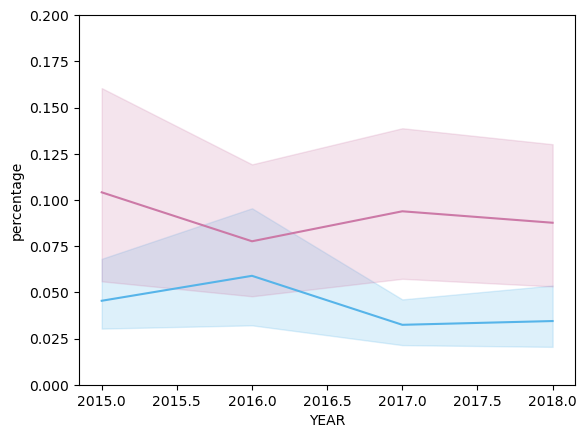

In [41]:
sns.lineplot(data=transport_usage[(transport_usage['TRANSPORT']=='Public') &\
                                 (transport_usage['YEAR'].isin(range(2015,2020)))],\
         x='YEAR', y='percentage', hue='cluster', legend=False, palette=colors)
plt.ylim(0,0.2)

In [42]:
aux_1 = data[(~data['TRAVEL_TIME'].isna()) & (data['TRAVEL_TIME']>0)].groupby(['YEAR','CITY','TRANSPORT'])[['TRAVEL_TIME','INDIVIDUAL_EXPANSION_FACTOR']]\
            .apply(lambda x: np.sum(x['TRAVEL_TIME']*x['INDIVIDUAL_EXPANSION_FACTOR'])/x['INDIVIDUAL_EXPANSION_FACTOR'].sum()
                  ).reset_index()
aux_1.columns = ['YEAR','CITY','TRANSPORT','TRAVEL_TIME']
aux_1 = aux_1.merge(file_per_city, left_on=['CITY','YEAR'], right_on=['city','year'])

In [43]:
aux_1.head(2)

,YEAR,CITY,TRANSPORT,TRAVEL_TIME,Unnamed: 0,cluster,city,year,hotspots_cuts_1_dest,flow_hierarchy_dest,mean_mob_div,% of areas,Fraction of areas
0,2015,Arlington,Bicycle,34.705882,31,C1,Arlington,2015,0.886792,0.717881,0.831547,0.113208,0.113208
1,2015,Arlington,Private,27.934788,31,C1,Arlington,2015,0.886792,0.717881,0.831547,0.113208,0.113208


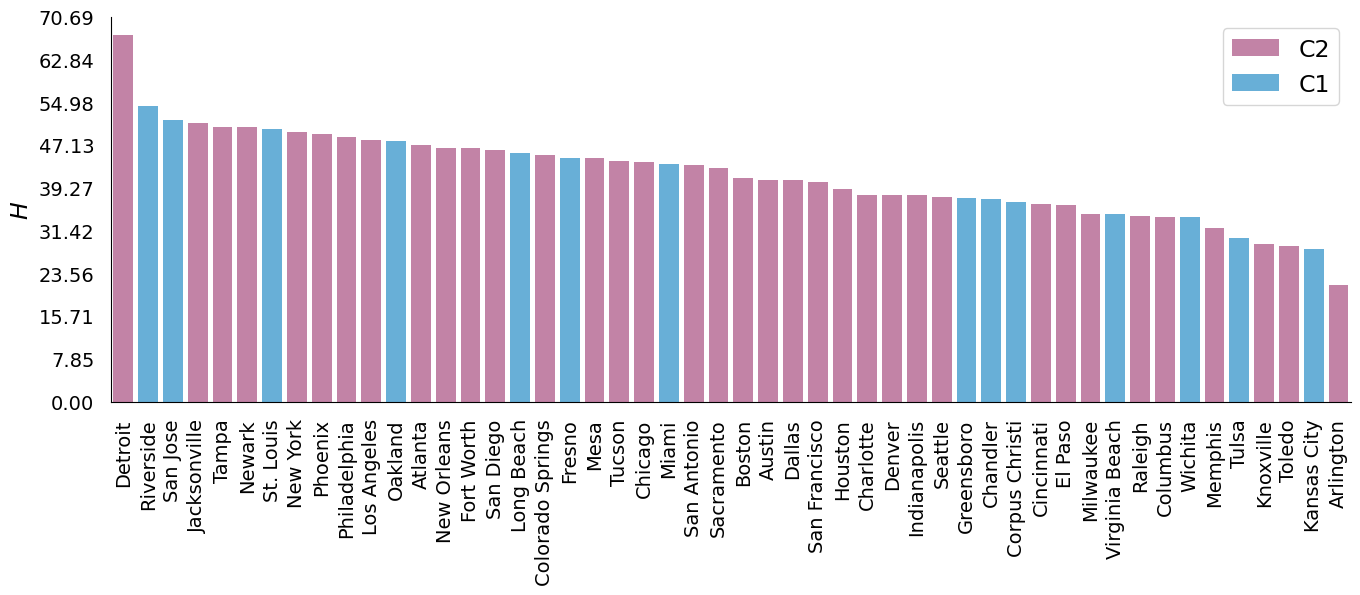

In [44]:
fontsize_all = 14
for year in range(2018,2019):
    fig, ax = plt.subplots(figsize=(16,5))
    sns.barplot(data=aux_1[(aux_1['YEAR']==year) & (aux_1['TRANSPORT']=='Public')].sort_values(by='TRAVEL_TIME', ascending=False),\
                x='CITY', y='TRAVEL_TIME',dodge=False,
                hue='cluster', palette=colors, ax=ax)
    leg = ax.legend(loc='upper right',fontsize=17)
    for line in leg.get_lines():
        line.set_linewidth(3.0)

    ax.tick_params(axis='both',length=0,labelsize=fontsize_all,pad=12)
    ax.tick_params(axis='both',which='minor',length=2)
    ax.tick_params(axis='x',rotation=90)
    
#     ax.set_ylim(0.7,.91)
    sns.despine()
    import matplotlib.ticker as ticker
    ax.yaxis.set_major_locator(ticker.LinearLocator(numticks=10))
    y_fmt = ticker.FormatStrFormatter('%.2f')
    ax.yaxis.set_major_formatter(y_fmt)


    ax.set_ylabel("$H$",fontsize=17)
    ax.set_xlabel("",fontsize=17)
    plt.savefig("order_mean_mob_div_%d.pdf"%year,  bbox_inches="tight")

In [53]:
file_per_city.head()

,Unnamed: 0,cluster,city,year,hotspots_cuts_1_dest,flow_hierarchy_dest,mean_mob_div,% of areas,Fraction of areas
0,0,C2,San Antonio,2015,0.958974,0.541743,0.858907,0.041026,0.041026
1,1,C1,Austin,2015,0.959677,0.684295,0.836378,0.040323,0.040323
2,2,C2,Houston,2015,0.984513,0.569376,0.828999,0.015487,0.015487
3,3,C1,Corpus Christi,2015,0.902439,0.781097,0.878937,0.097561,0.097561
4,4,C2,New Orleans,2015,0.924528,0.633396,0.751296,0.075472,0.075472


In [57]:
aux_1 = data[(~data['TRAVEL_TIME'].isna()) & (data['TRAVEL_TIME']>=0)].groupby(['YEAR','CITY','TRANSPORT','GENDER'])[['TRAVEL_TIME','INDIVIDUAL_EXPANSION_FACTOR']]\
            .apply(lambda x: np.sum(x['TRAVEL_TIME']*x['INDIVIDUAL_EXPANSION_FACTOR'])/x['INDIVIDUAL_EXPANSION_FACTOR'].sum()
                  ).reset_index()
aux_1.columns = ['YEAR','CITY','TRANSPORT','GENDER','TRAVEL_TIME']
aux_1 = aux_1.merge(file_per_city, left_on=['CITY','YEAR'], right_on=['city','year'])

aux_2 = aux_1.pivot_table(columns='GENDER',\
                    index=['CITY','YEAR','cluster'], values='TRAVEL_TIME', aggfunc='mean').reset_index()

aux_2['diff'] = aux_2['Men'] - aux_2['Women']
aux_2['diff_abs'] = aux_2['diff'].abs()
aux_2.head()

GENDER,CITY,YEAR,cluster,Men,Women,diff,diff_abs
0,Arlington,2015,C1,34.730789,28.916083,5.814706,5.814706
1,Arlington,2016,C2,22.340681,37.259422,-14.918741,14.918741
2,Arlington,2017,C2,34.234712,24.722153,9.512558,9.512558
3,Arlington,2018,C2,23.023379,14.530420,8.492960,8.492960
4,Atlanta,2015,C1,29.422629,27.053050,2.369578,2.369578


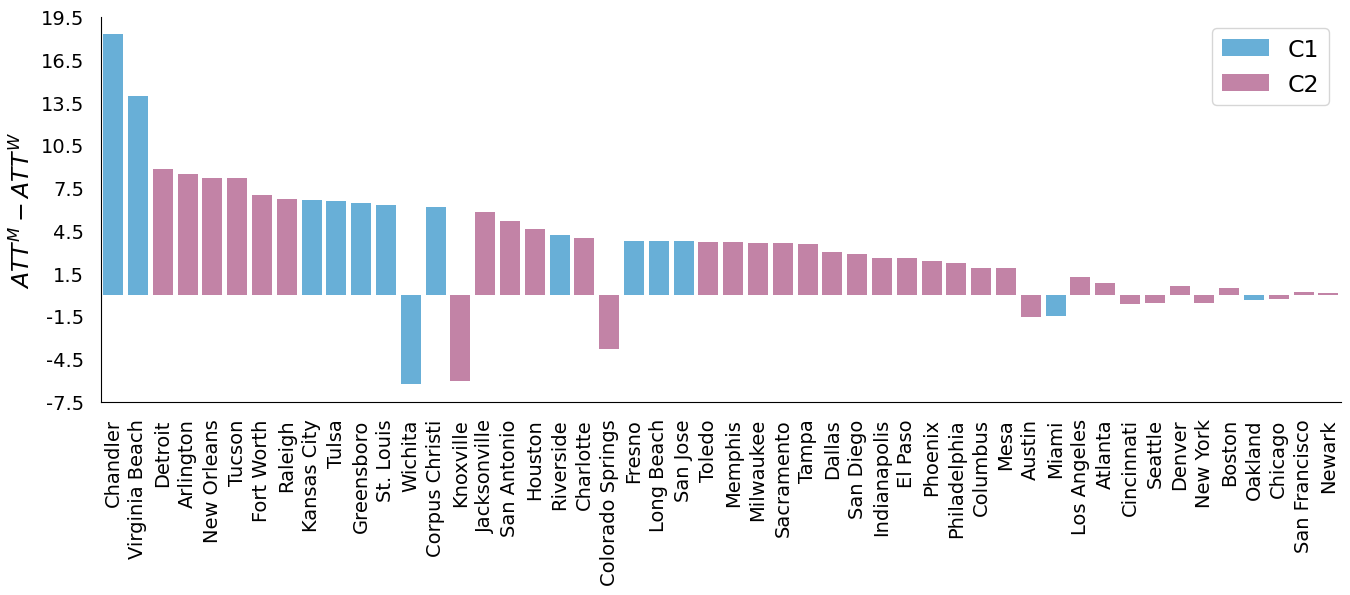

In [58]:
fontsize_all = 14
for year in range(2018,2019):
    fig, ax = plt.subplots(figsize=(16,5))
    sns.barplot(data=aux_2[(aux_2['YEAR']==year)].sort_values(by='diff_abs', ascending=False),\
                x='CITY', y='diff',dodge=False,
                hue='cluster', palette=colors, ax=ax)
    leg = ax.legend(loc='upper right',fontsize=17)
    for line in leg.get_lines():
        line.set_linewidth(3.0)

    ax.tick_params(axis='both',length=0,labelsize=fontsize_all,pad=12)
    ax.tick_params(axis='both',which='minor',length=2)
    ax.tick_params(axis='x',rotation=90)
    
    # ax.set_ylim(-10,10)
    sns.despine()
    import matplotlib.ticker as ticker
    ax.yaxis.set_major_locator(ticker.LinearLocator(numticks=10))
    y_fmt = ticker.FormatStrFormatter('%.1f')
    ax.yaxis.set_major_formatter(y_fmt)


    ax.set_ylabel("$ATT^{M} - ATT^{W}$",fontsize=17)
    ax.set_xlabel("",fontsize=17)
    plt.savefig("order_att_diff_%d.pdf"%year,  bbox_inches="tight")

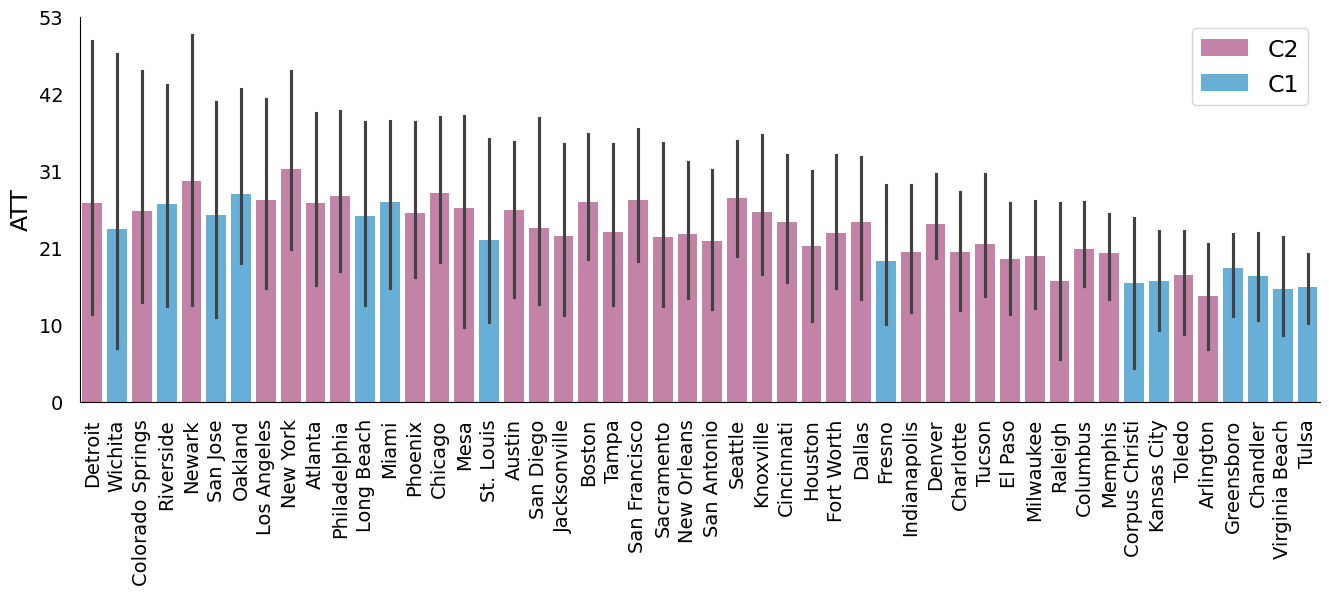

In [50]:
fontsize_all = 14
for year in range(2018,2019):
    fig, ax = plt.subplots(figsize=(16,5))
    sns.barplot(data=aux_1[(aux_1['YEAR']==year) & (aux_1['GENDER']=="Women")].sort_values(by='TRAVEL_TIME', ascending=False),\
                x='CITY', y='TRAVEL_TIME',
                hue='cluster', palette=colors, ax=ax)
    leg = ax.legend(loc='upper right',fontsize=17)
    for line in leg.get_lines():
        line.set_linewidth(3.0)

    ax.tick_params(axis='both',length=0,labelsize=fontsize_all,pad=12)
    ax.tick_params(axis='both',which='minor',length=2)
    ax.tick_params(axis='x',rotation=90)
    
#     ax.set_ylim(0,10)
    sns.despine()
    import matplotlib.ticker as ticker
    ax.yaxis.set_major_locator(ticker.LinearLocator(numticks=6))
    y_fmt = ticker.FormatStrFormatter('%d')
    ax.yaxis.set_major_formatter(y_fmt)


    ax.set_ylabel("ATT",fontsize=17)
    ax.set_xlabel("",fontsize=17)
    plt.savefig("order_att_%d.pdf"%year,  bbox_inches="tight")

In [13]:
data['INDIVIDUAL_EXPANSION_FACTOR'] = data['INDIVIDUAL_EXPANSION_FACTOR'].fillna(0).abs()
subset = data[['CITY','YEAR','TRANSPORT_2','INDIVIDUAL_EXPANSION_FACTOR','cluster']].copy()
# subset = subset.loc[subset.index.repeat(subset['INDIVIDUAL_EXPANSION_FACTOR'])].copy()
aux_1 = subset.groupby(['CITY','YEAR','TRANSPORT_2','cluster'])['INDIVIDUAL_EXPANSION_FACTOR'].sum().reset_index()

aux_1['total']= None
for row in aux_1.groupby(['CITY','YEAR','cluster'])['INDIVIDUAL_EXPANSION_FACTOR'].sum().reset_index().iterrows():
    aux_1.loc[(aux_1['CITY']==row[1]['CITY']) &\
              (aux_1['YEAR']==row[1]['YEAR']),'total'] = row[1]['INDIVIDUAL_EXPANSION_FACTOR']
aux_1['percentage'] = aux_1['INDIVIDUAL_EXPANSION_FACTOR']*100/aux_1['total']
aux_1.tail(6)

,CITY,YEAR,TRANSPORT_2,cluster,INDIVIDUAL_EXPANSION_FACTOR,total,percentage
394,Wichita,2016,Private,C2,76438,82978,92.118393
395,Wichita,2016,Public,C2,6540,82978,7.881607
396,Wichita,2017,Private,C1,73867,81449,90.691107
397,Wichita,2017,Public,C1,7582,81449,9.308893
398,Wichita,2018,Private,C1,74604,81168,91.913069
399,Wichita,2018,Public,C1,6564,81168,8.086931


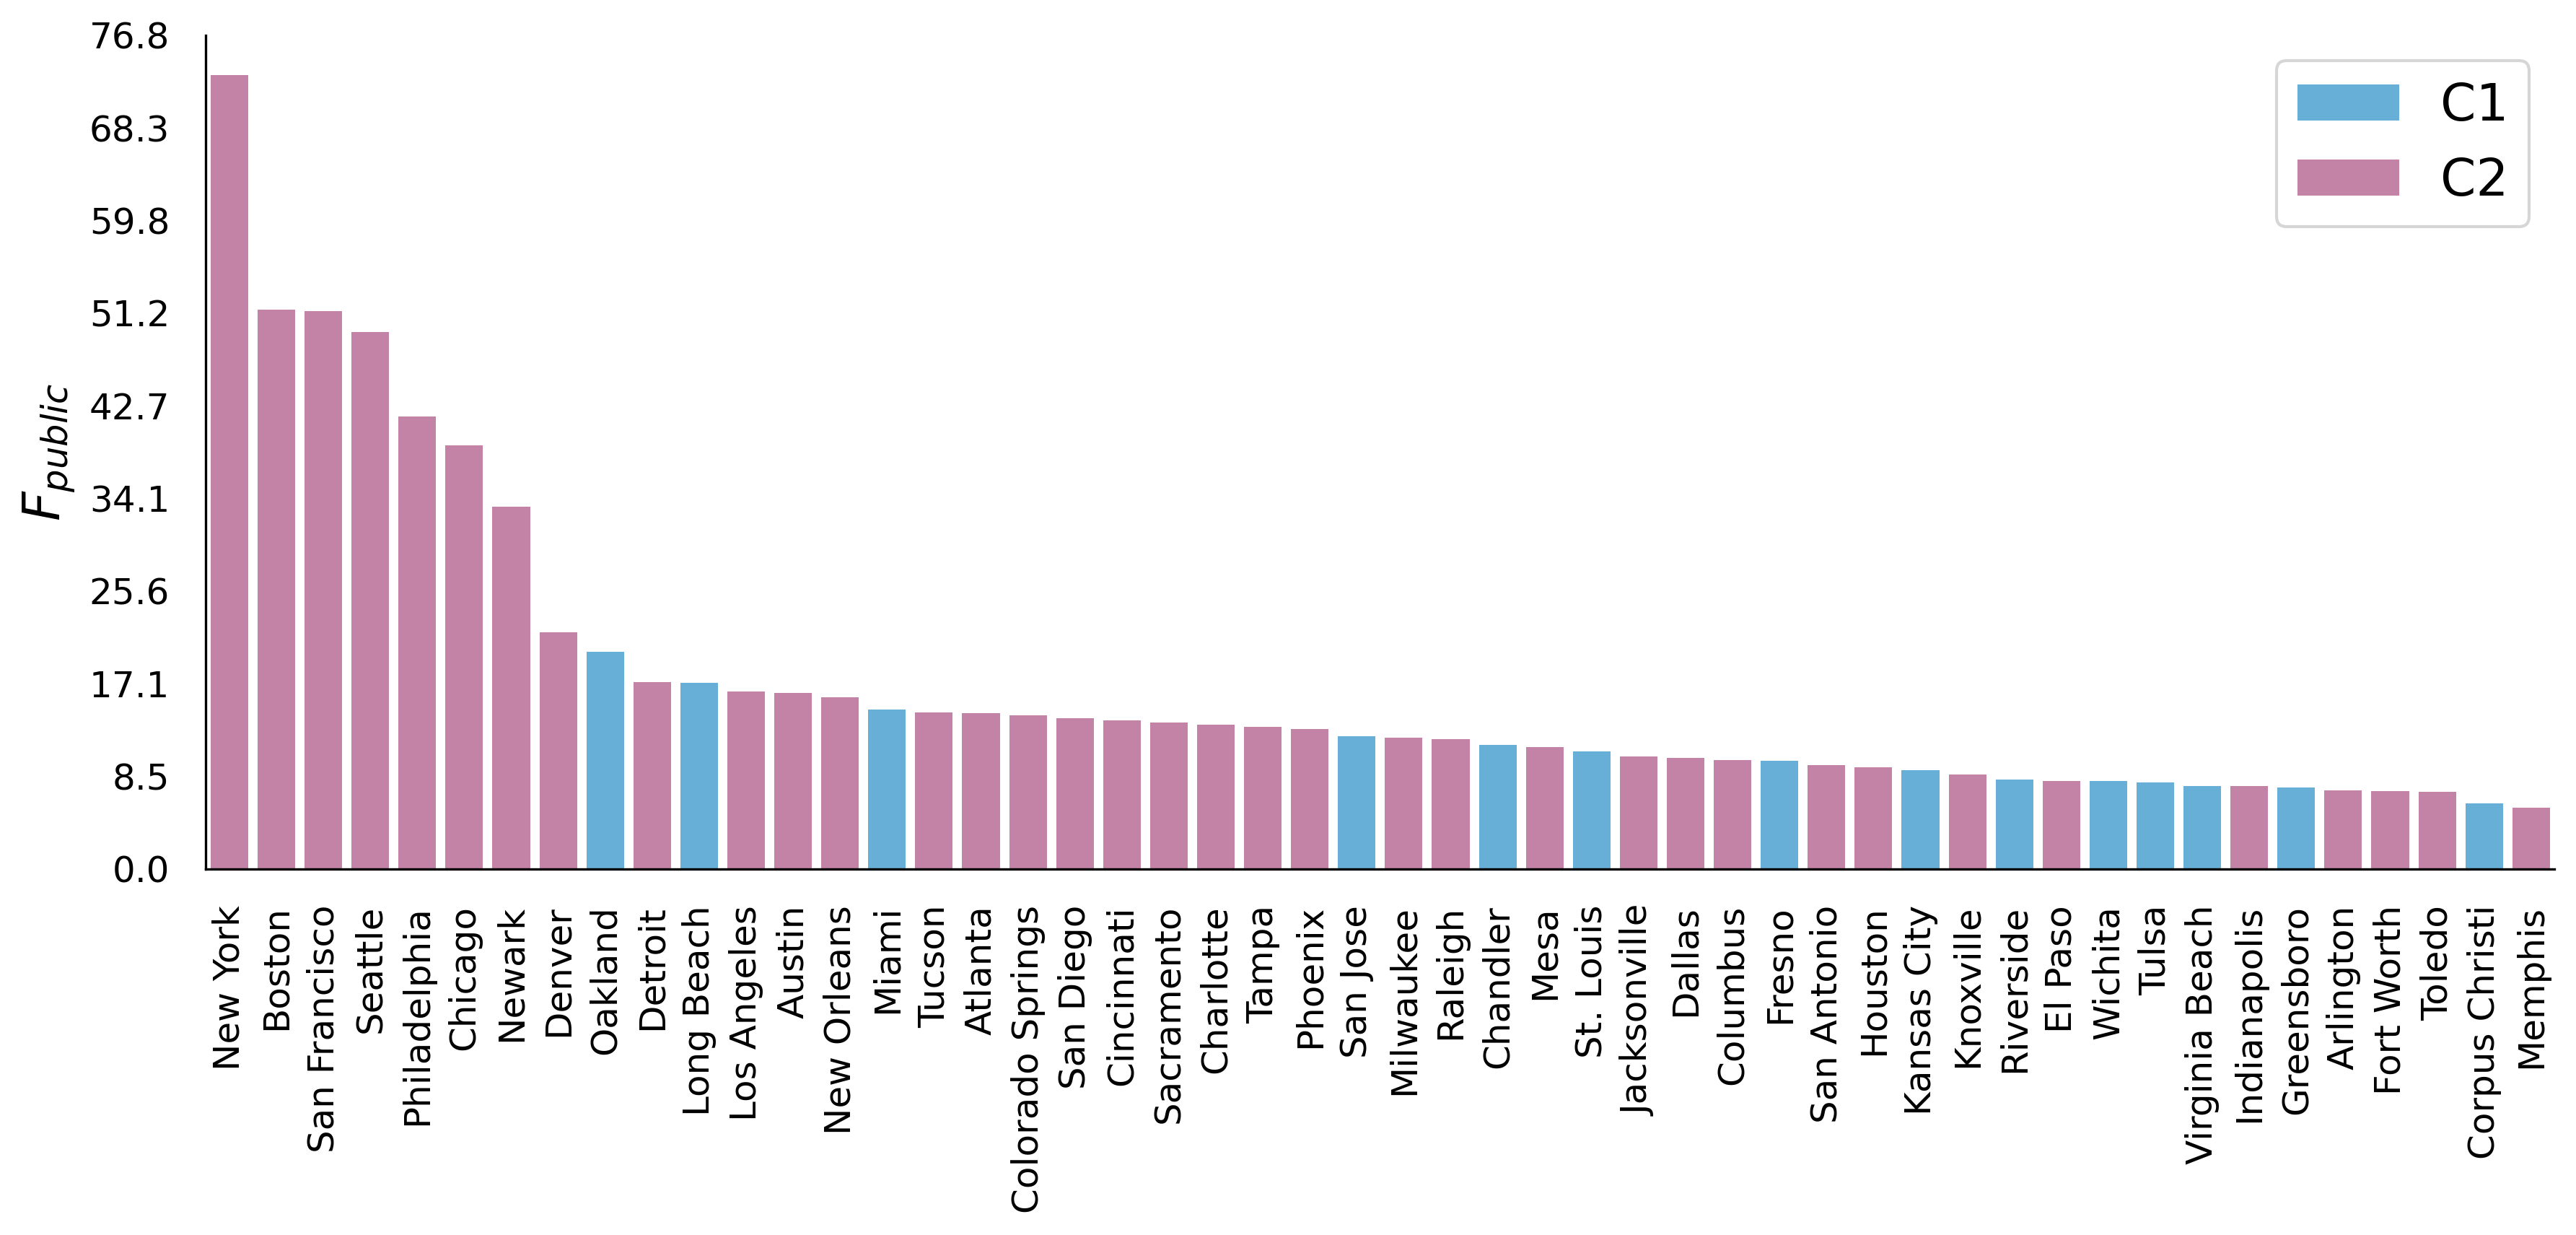

In [15]:
fontsize_all = 12
for year in range(2018,2019):
    fig, ax = plt.subplots(figsize=(14,5), dpi=300)
    sns.barplot(data=aux_1[(aux_1['YEAR']==year) & (aux_1['TRANSPORT_2']=='Public')].sort_values(by='percentage', ascending=False),\
                x='CITY', y='percentage', dodge=False,
                hue='cluster',hue_order=['C1','C2'], palette=colors,ax=ax)
    
#     change_width(ax, .55)
    leg = ax.legend(loc='upper right',fontsize=17)
    for line in leg.get_lines():
        line.set_linewidth(3.0)

    ax.tick_params(axis='both',length=0,labelsize=fontsize_all,pad=12)
    ax.tick_params(axis='both',which='minor',length=2)
    ax.tick_params(axis='x',rotation=90)
    
#     ax.set_ylim(-10,10)
    sns.despine()
    import matplotlib.ticker as ticker
    ax.yaxis.set_major_locator(ticker.LinearLocator(numticks=10))
    y_fmt = ticker.FormatStrFormatter('%.1f')
    ax.yaxis.set_major_formatter(y_fmt)


    ax.set_ylabel("$F_{public}$",fontsize=17)
    ax.set_xlabel("",fontsize=17)
    plt.savefig("order_public_percentage_%d.pdf"%year,  bbox_inches="tight")

In [16]:
data['INDIVIDUAL_EXPANSION_FACTOR'] = data['INDIVIDUAL_EXPANSION_FACTOR'].fillna(0).abs()
subset = data[['CITY','YEAR','TRANSPORT','INDIVIDUAL_EXPANSION_FACTOR','cluster','GENDER']].copy()
# subset = subset.loc[subset.index.repeat(subset['INDIVIDUAL_EXPANSION_FACTOR'])].copy()
aux_1 = subset.groupby(['CITY','YEAR','TRANSPORT','cluster','GENDER'])['INDIVIDUAL_EXPANSION_FACTOR'].sum().reset_index()

aux_1['total']= None
for row in aux_1.groupby(['CITY','YEAR','cluster','GENDER'])['INDIVIDUAL_EXPANSION_FACTOR'].sum().reset_index().iterrows():
    aux_1.loc[(aux_1['CITY']==row[1]['CITY']) &\
              (aux_1['YEAR']==row[1]['YEAR']) &\
              (aux_1['GENDER']==row[1]['GENDER']),'total'] = row[1]['INDIVIDUAL_EXPANSION_FACTOR']
aux_1['percentage'] = aux_1['INDIVIDUAL_EXPANSION_FACTOR']*100/aux_1['total']
aux_1.tail(6)

,CITY,YEAR,TRANSPORT,cluster,GENDER,INDIVIDUAL_EXPANSION_FACTOR,total,percentage
1584,Wichita,2018,Private,C1,Men,39448,43087,91.554297
1585,Wichita,2018,Private,C1,Women,35156,38081,92.319004
1586,Wichita,2018,Public,C1,Men,777,43087,1.803328
1587,Wichita,2018,Public,C1,Women,420,38081,1.102912
1588,Wichita,2018,Walk,C1,Men,2553,43087,5.925221
1589,Wichita,2018,Walk,C1,Women,2480,38081,6.512434


/var/folders/4w/mcfy5tkx03s7_vlsqdf934z80000gn/T/ipykernel_23831/1869328889.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  index=['CITY','YEAR','cluster'], values='percentage', aggfunc='sum').reset_index().fillna(0)


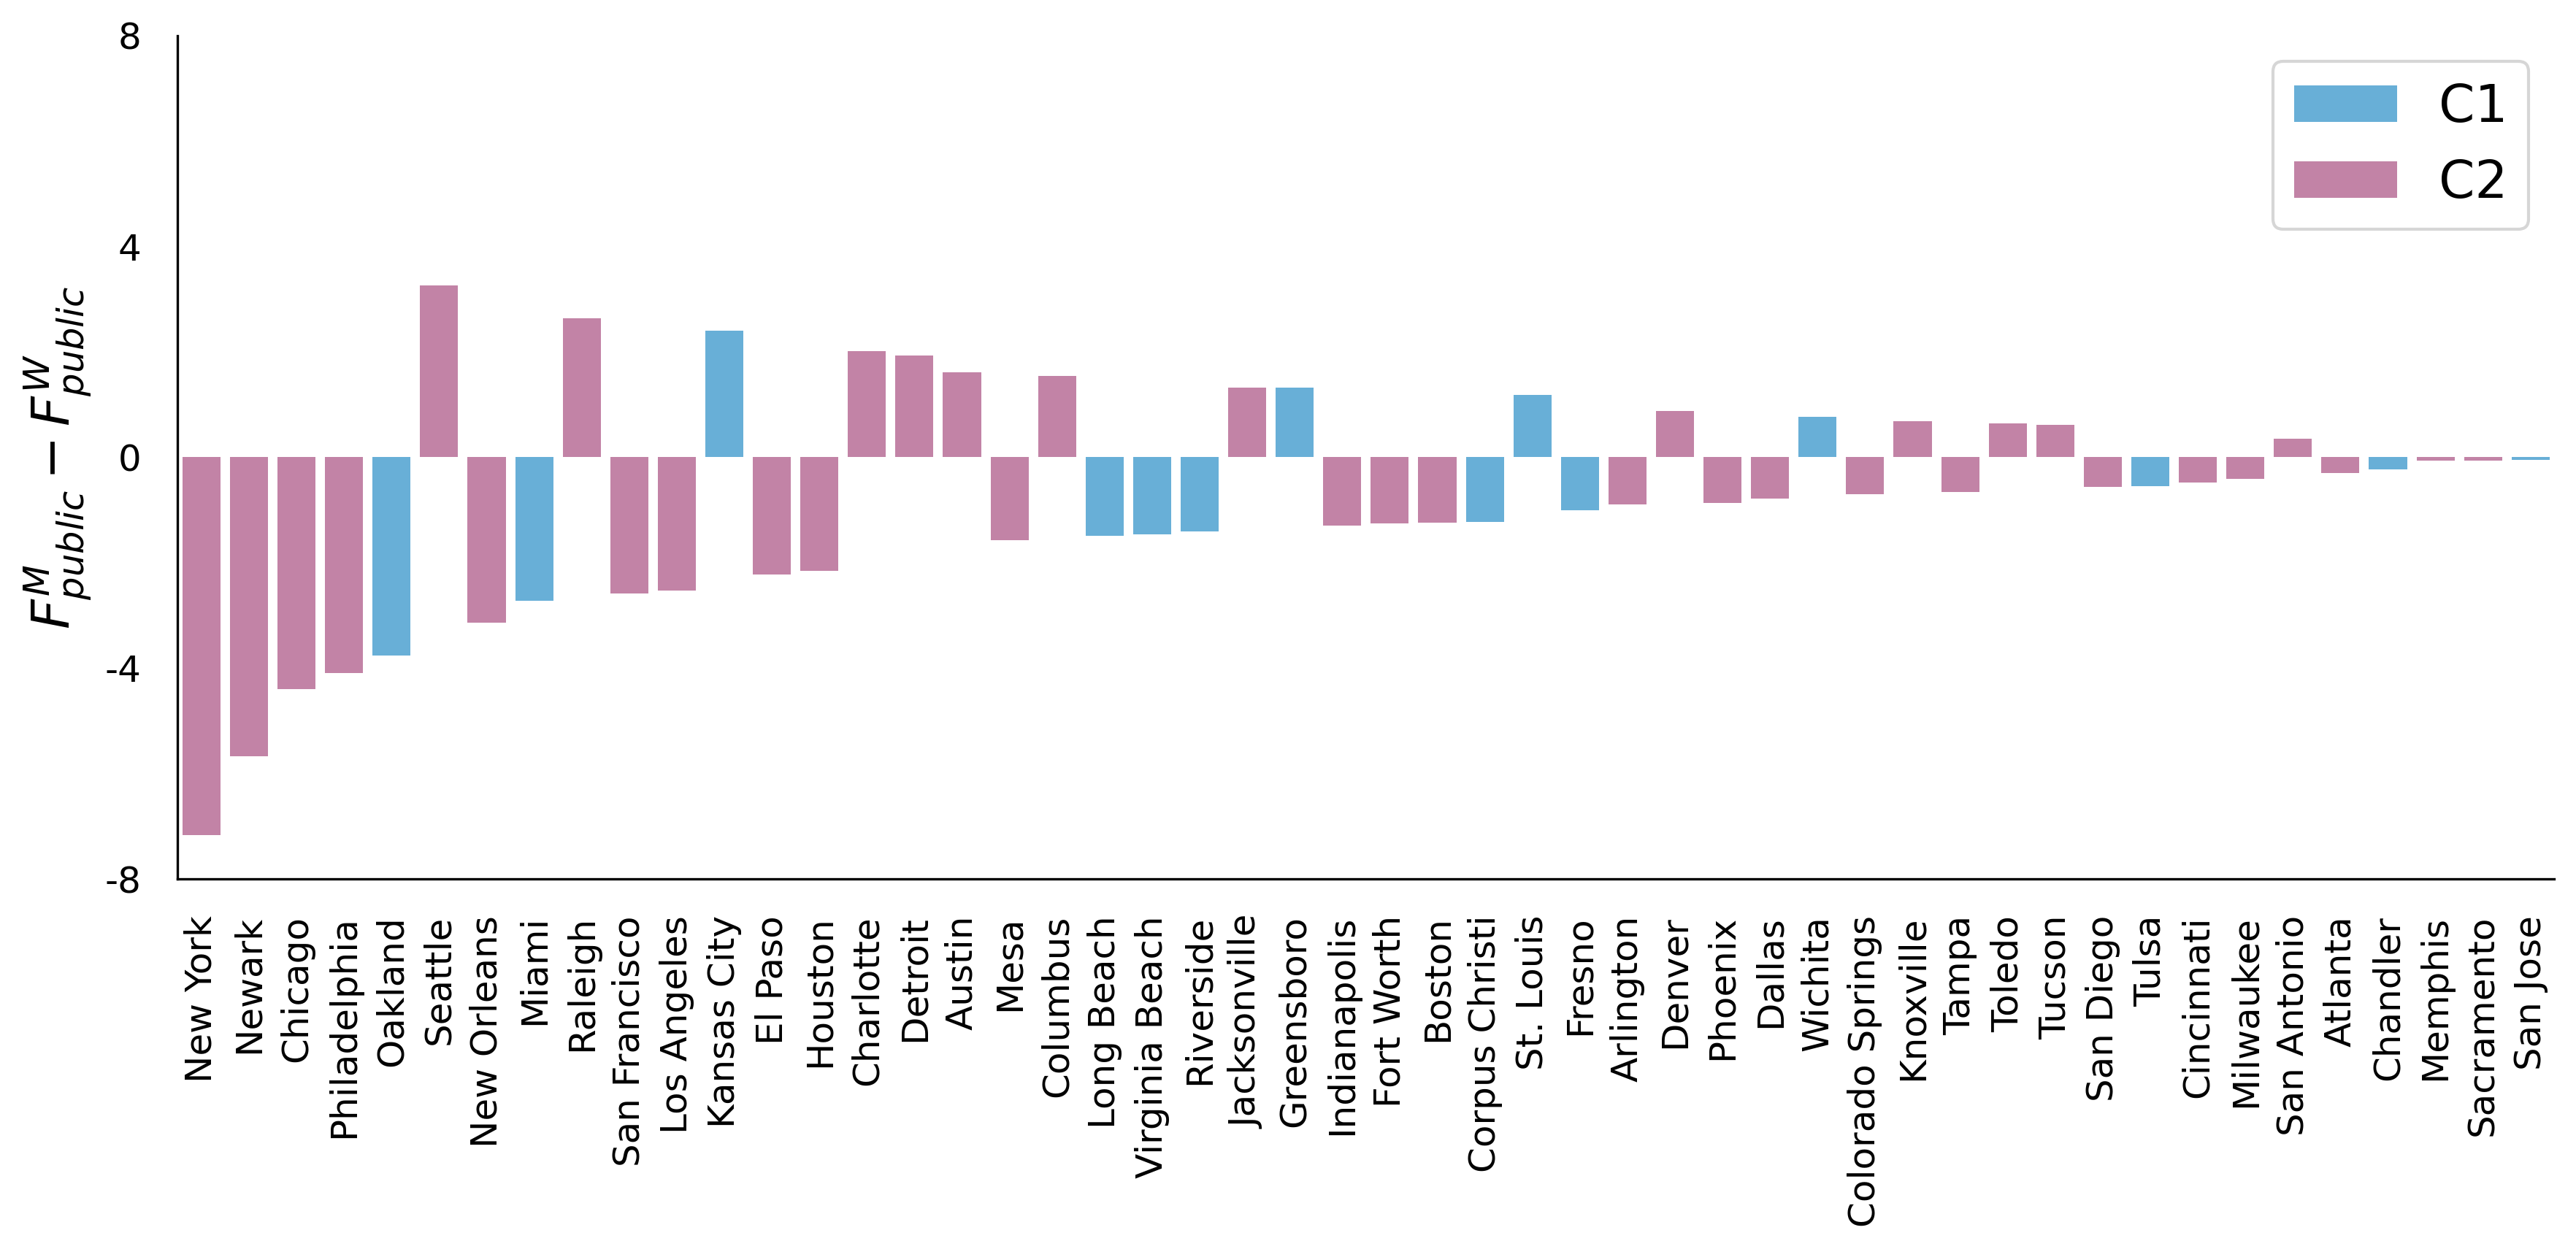

In [18]:
aux_2 = aux_1[aux_1['TRANSPORT']!='Private'].pivot_table(columns='GENDER',\
                    index=['CITY','YEAR','cluster'], values='percentage', aggfunc='sum').reset_index().fillna(0)
aux_2['diff'] = aux_2['Men'] - aux_2['Women']
aux_2['diff_abs'] = aux_2['diff'].abs()
aux_2.head()

fontsize_all = 12
for year in range(2018,2019):
    fig, ax = plt.subplots(figsize=(14,5), dpi=300)
    sns.barplot(data=aux_2[(aux_2['YEAR']==year)].sort_values(by='diff_abs', ascending=False),\
                x='CITY', y='diff', dodge=False,
                hue='cluster', hue_order=['C1','C2'], palette=colors,ax=ax)
    
#     change_width(ax, .55)
    leg = ax.legend(loc='upper right',fontsize=17)
    for line in leg.get_lines():
        line.set_linewidth(3.0)

    ax.tick_params(axis='both',length=0,labelsize=fontsize_all,pad=12)
    ax.tick_params(axis='both',which='minor',length=2)
    ax.tick_params(axis='x',rotation=90)
    
    ax.set_ylim(-8,8)
    sns.despine()
    import matplotlib.ticker as ticker
    ax.yaxis.set_major_locator(ticker.LinearLocator(numticks=5))
    y_fmt = ticker.FormatStrFormatter('%.d')
    ax.yaxis.set_major_formatter(y_fmt)


    ax.set_ylabel("$F^{M}_{public} - F^{W}_{public}$",fontsize=17)
    ax.set_xlabel("",fontsize=17)
    plt.savefig("order_public_diff_%d.pdf"%year,  bbox_inches="tight")

/var/folders/4w/mcfy5tkx03s7_vlsqdf934z80000gn/T/ipykernel_23831/867455305.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  index=['CITY','YEAR','cluster'], values='percentage', aggfunc='sum').reset_index().fillna(0)


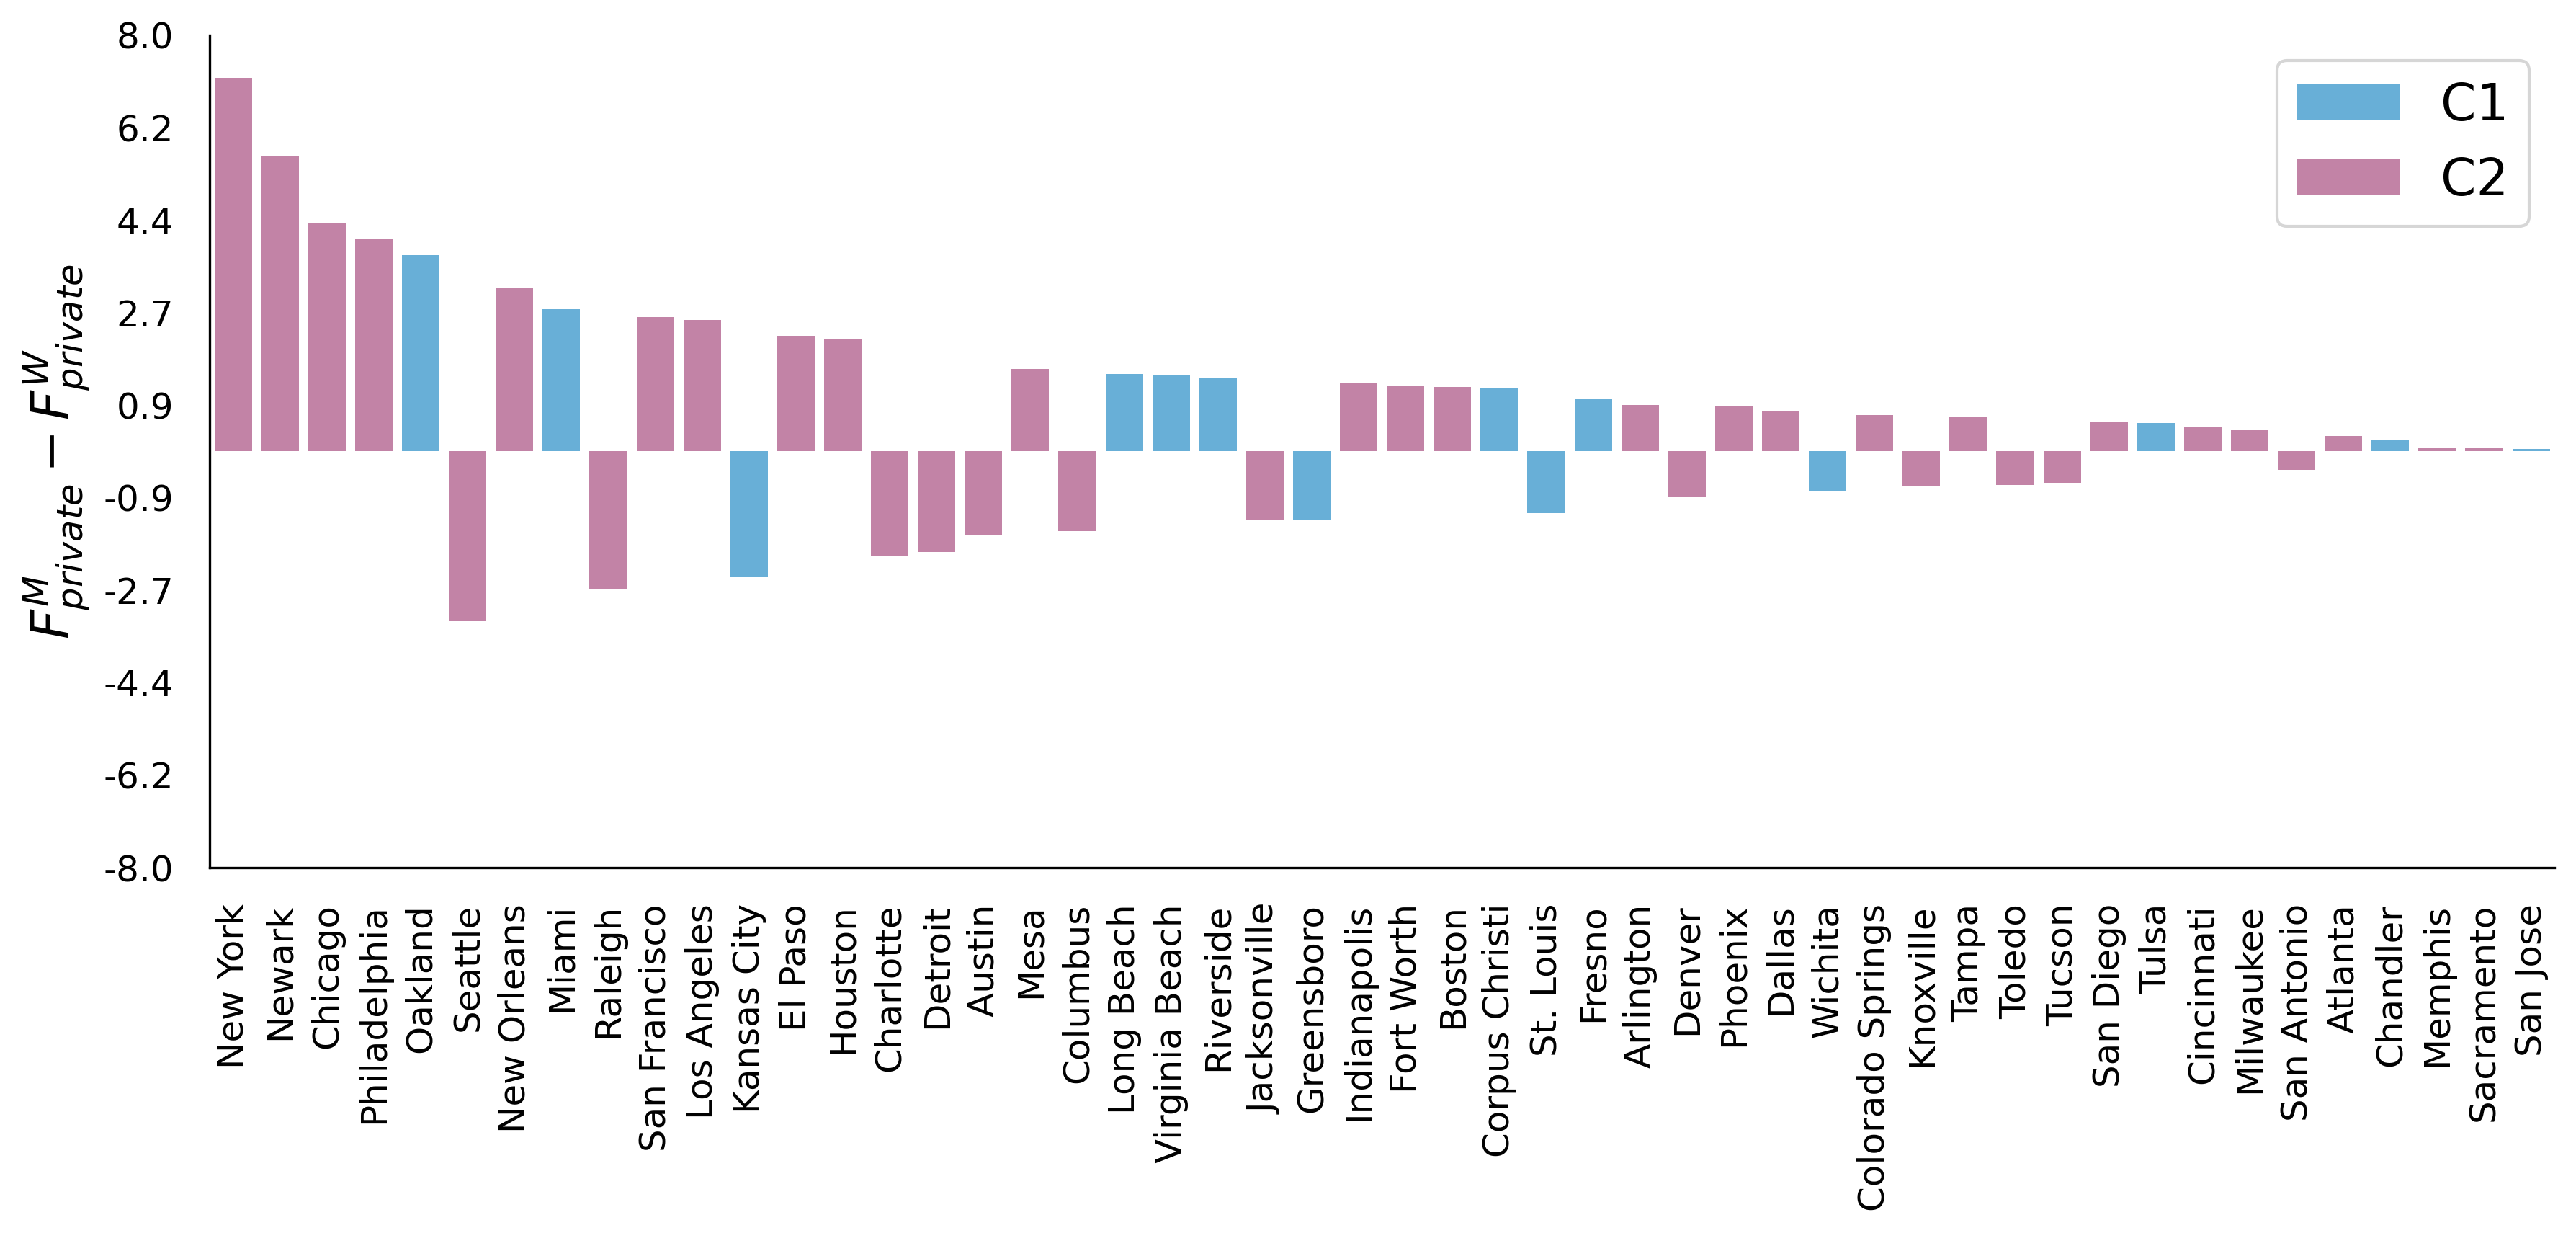

In [20]:
aux_2 = aux_1[aux_1['TRANSPORT']=='Private'].pivot_table(columns='GENDER',\
                    index=['CITY','YEAR','cluster'], values='percentage', aggfunc='sum').reset_index().fillna(0)
aux_2['diff'] = aux_2['Men'] - aux_2['Women']
aux_2['diff_abs'] = aux_2['diff'].abs()
aux_2.head()

fontsize_all = 12
for year in range(2018,2019):
    fig, ax = plt.subplots(figsize=(14,5), dpi=300)
    sns.barplot(data=aux_2[(aux_2['YEAR']==year)].sort_values(by='diff_abs', ascending=False),\
                x='CITY', y='diff', dodge=False,
                hue='cluster', hue_order=['C1','C2'], palette=colors,ax=ax)
    
#     change_width(ax, .55)
    leg = ax.legend(loc='upper right',fontsize=17)
    for line in leg.get_lines():
        line.set_linewidth(3.0)

    ax.tick_params(axis='both',length=0,labelsize=fontsize_all,pad=12)
    ax.tick_params(axis='both',which='minor',length=2)
    ax.tick_params(axis='x',rotation=90)
    
    ax.set_ylim(-8,8)
    sns.despine()
    import matplotlib.ticker as ticker
    ax.yaxis.set_major_locator(ticker.LinearLocator(numticks=10))
    y_fmt = ticker.FormatStrFormatter('%.1f')
    ax.yaxis.set_major_formatter(y_fmt)


    ax.set_ylabel("$F^{M}_{private} - F^{W}_{private}$",fontsize=17)
    ax.set_xlabel("",fontsize=17)
    plt.savefig("order_private_diff_%d.pdf"%year,  bbox_inches="tight")

In [21]:
def change_width(ax, new_value) :
    for patch in ax.patches :
        current_width = patch.get_width()
        diff = current_width - new_value

        # we change the bar width
        patch.set_width(new_value)

        # we recenter the bar
        patch.set_x(patch.get_x() + diff * .5)

In [22]:
colors['Women C1'] = "#E69F00"
colors['Women C2'] = "#D55E00"
colors['Men C1'] = "#009E73"
colors['Men C2'] = "#0072B2"


In [24]:
one_df = pd.read_csv("datasets/cities_OSM.csv")
one_df.head()

,Unnamed: 0,state,city,puma,distance_to_centroid_meters,ALL_CAT,ALL_CAT_COUNT,AMENITY_CAT,AMENITY_CAT_COUNT,BUILDING_CAT,BUILDING_CAT_COUNT,HIGHWAY_CAT,HIGHWAY_CAT_COUNT
0,0,Texas,Arlington,2500,500,0,23,0,23,0,23,0,23
1,1,Texas,Arlington,2500,1000,0,169,0,169,0,169,0,169
2,2,Texas,Arlington,2500,1500,0,336,0,336,0,336,0,336
3,3,Texas,Arlington,2500,2000,0,558,0,558,0,558,0,558
4,4,Texas,Arlington,2500,2500,0,743,0,743,0,743,0,743


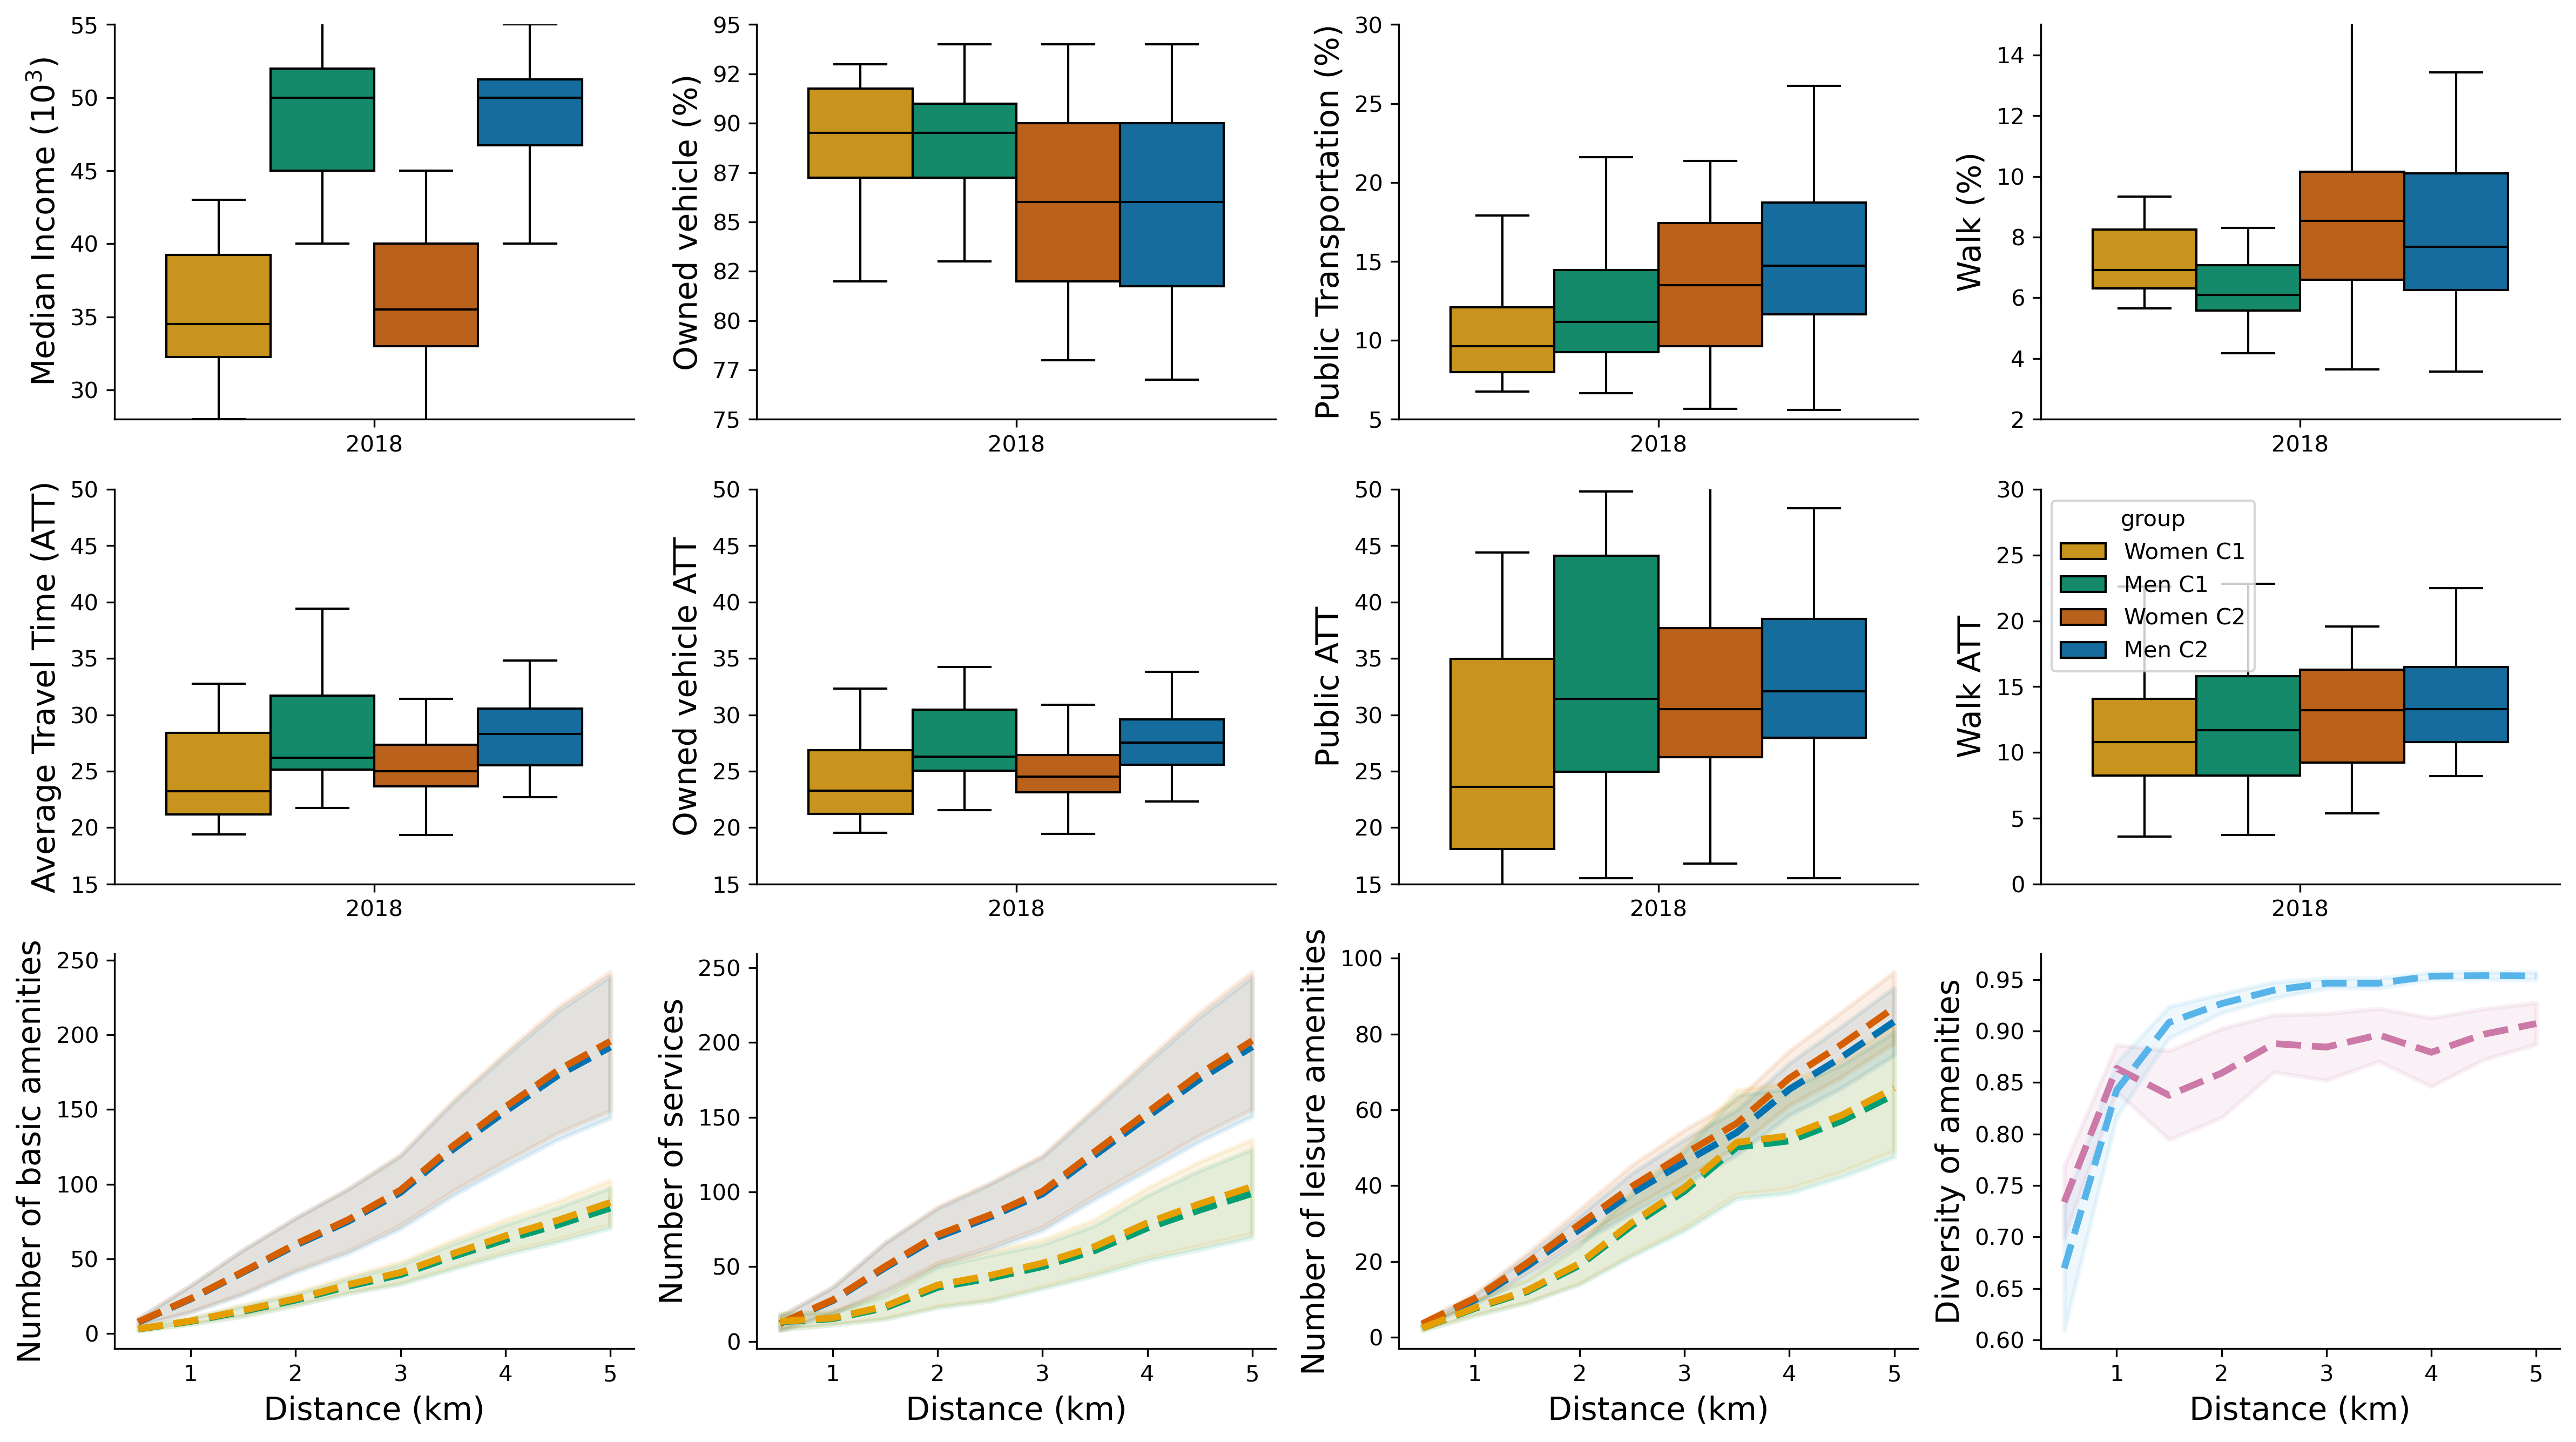

In [25]:
from scipy import stats
from scipy.stats import sem, t
confidence = 0.9
def get_error(a,each_result):
    if len(a) > 0:
        return sem(a[1][each_result], nan_policy='omit') * t.ppf((1 + confidence) / 2., len((a[1][each_result])-1))
    return 0

fig, ax = plt.subplots(ncols=4, nrows=3, figsize=(4*4, 3*3), dpi=300)
import matplotlib.ticker as ticker
for each_row in range(3):
    for each_col in range(4):
        
        if each_col == 1 and each_row ==0:
            subset = data[['CITY','YEAR','GENDER','MODE_OF_TRANSPORTATION_TO_WORK_MM','INDIVIDUAL_EXPANSION_FACTOR']].copy()
            aux_1 = subset.groupby(['CITY','YEAR','GENDER','MODE_OF_TRANSPORTATION_TO_WORK_MM'])['INDIVIDUAL_EXPANSION_FACTOR'].sum().reset_index()
            aux_1 = aux_1.merge(file_per_city, left_on=['CITY','YEAR'], right_on=['city','year'])
            aux_1['total']= None
            for row in aux_1.groupby(['CITY','YEAR','GENDER'])['INDIVIDUAL_EXPANSION_FACTOR'].sum().reset_index().iterrows():
                aux_1.loc[(aux_1['CITY']==row[1]['CITY']) &\
                          (aux_1['YEAR']==row[1]['YEAR'])&\
                          (aux_1['GENDER']==row[1]['GENDER']),'total'] = row[1]['INDIVIDUAL_EXPANSION_FACTOR']
            aux_1['percentage'] = aux_1['INDIVIDUAL_EXPANSION_FACTOR']*100/aux_1['total']
            aux_1['percentage'] = aux_1['percentage'].astype(int)
            aux_1['group'] = aux_1['GENDER'].apply(str) + " " + aux_1['cluster'].apply(str)
            sns.boxplot(x='year', 
                    y='percentage', fliersize=0,
                    data=aux_1[(aux_1['MODE_OF_TRANSPORTATION_TO_WORK_MM']=='Car, truck, or van') & 
                              (aux_1['year']==2018)].sort_values(by='cluster'),\
                        hue_order=['Women C1','Men C1','Women C2','Men C2'],
                        hue='group', palette=colors, ax=ax[each_row][each_col])
            ax[each_row][each_col].set_ylim(75, 95)
            ax[each_row][each_col].yaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))
            ax[each_row][each_col].set_xlabel("")
            ax[each_row][each_col].get_legend().remove()
            ax[each_row][each_col].set_ylabel("Owned vehicle (%)", fontsize=14)
            del aux_1
        elif each_col == 2 and each_row ==0:
            subset = data[['CITY','YEAR','GENDER','TRANSPORT_2','INDIVIDUAL_EXPANSION_FACTOR']].copy()
            aux_1 = subset.groupby(['CITY','YEAR','GENDER','TRANSPORT_2'])['INDIVIDUAL_EXPANSION_FACTOR'].sum().reset_index()
            aux_1 = aux_1.merge(file_per_city, left_on=['CITY','YEAR'], right_on=['city','year'])
            aux_1['total']= None
            for row in aux_1.groupby(['CITY','YEAR','GENDER'])['INDIVIDUAL_EXPANSION_FACTOR'].sum().reset_index().iterrows():
                aux_1.loc[(aux_1['CITY']==row[1]['CITY']) &\
                          (aux_1['YEAR']==row[1]['YEAR']),'total'] = row[1]['INDIVIDUAL_EXPANSION_FACTOR']
            aux_1['percentage'] = aux_1['INDIVIDUAL_EXPANSION_FACTOR']*100/aux_1['total']
            aux_1['group'] = aux_1['GENDER'].apply(str) + " " + aux_1['cluster'].apply(str)
            sns.boxplot(x='year', 
                    y='percentage', fliersize=0,
                    data=aux_1[(aux_1['TRANSPORT_2']=="Public") & 
                              (aux_1['year']==2018)].sort_values(by='cluster'),\
                        hue_order=['Women C1','Men C1','Women C2','Men C2'],\
                        hue='group', palette=colors, ax=ax[each_row][each_col])
            ax[each_row][each_col].set_ylim(5, 30)
            ax[each_row][each_col].set_xlabel("")
            ax[each_row][each_col].get_legend().remove()
            ax[each_row][each_col].set_ylabel("Public Transportation (%)", fontsize=14)
            del aux_1
        elif each_col == 3 and each_row ==0:
            subset = data[['CITY','YEAR','GENDER','TRANSPORT','INDIVIDUAL_EXPANSION_FACTOR']].copy()
            aux_1 = subset.groupby(['CITY','YEAR','GENDER','TRANSPORT'])['INDIVIDUAL_EXPANSION_FACTOR'].sum().reset_index()
            aux_1 = aux_1.merge(file_per_city, left_on=['CITY','YEAR'], right_on=['city','year'])
            aux_1['total']= None
            for row in aux_1.groupby(['CITY','YEAR','GENDER'])['INDIVIDUAL_EXPANSION_FACTOR'].sum().reset_index().iterrows():
                aux_1.loc[(aux_1['CITY']==row[1]['CITY']) &\
                          (aux_1['YEAR']==row[1]['YEAR'])&\
                          (aux_1['GENDER']==row[1]['GENDER']),'total'] = row[1]['INDIVIDUAL_EXPANSION_FACTOR']
            aux_1['percentage'] = aux_1['INDIVIDUAL_EXPANSION_FACTOR']*100/aux_1['total']
            aux_1['group'] = aux_1['GENDER'].apply(str) + " " + aux_1['cluster'].apply(str)
            sns.boxplot(x='year', 
                    y='percentage', fliersize=0,
                    data=aux_1[(aux_1['TRANSPORT']=="Walk") & 
                              (aux_1['year']==2018)].sort_values(by='cluster'),\
                        hue='group', hue_order=['Women C1','Men C1','Women C2','Men C2'],
                        palette=colors, ax=ax[each_row][each_col])
            ax[each_row][each_col].set_ylim(2, 15)
            ax[each_row][each_col].get_legend().remove()
            ax[each_row][each_col].set_xlabel("")
            ax[each_row][each_col].set_ylabel("Walk (%)", fontsize=14)
            del aux_1
            
        elif each_col == 0 and each_row ==1:
            aux_1 = data[(~data['TRAVEL_TIME'].isna()) & (data['TRAVEL_TIME']>0) & (data['TRAVEL_TIME']>0)
                        & (data['RELATIONSHIP'].isin([20,21]))].groupby(['YEAR','CITY','GENDER'])[['TRAVEL_TIME','INDIVIDUAL_EXPANSION_FACTOR']]\
                        .apply(lambda x: np.sum(x['TRAVEL_TIME']*x['INDIVIDUAL_EXPANSION_FACTOR'])/x['INDIVIDUAL_EXPANSION_FACTOR'].sum()
                              ).reset_index()
            aux_1.columns = ['YEAR','CITY','GENDER','TRAVEL_TIME']
            aux_1 = aux_1.merge(file_per_city, left_on=['CITY','YEAR'], right_on=['city','year'])
            aux_1['group'] = aux_1['GENDER'].apply(str) + " " + aux_1['cluster'].apply(str)
            sns.boxplot(x='year', 
                    y='TRAVEL_TIME', fliersize=0,
                    data=aux_1[(aux_1['year']==2018)].sort_values(by='cluster'),\
                        hue='group', palette=colors,hue_order=['Women C1','Men C1','Women C2','Men C2'],
                        ax=ax[each_row][each_col])
            ax[each_row][each_col].set_ylim(15, 50)
            ax[each_row][each_col].get_legend().remove()
            ax[each_row][each_col].set_xlabel("")
            ax[each_row][each_col].set_ylabel("Average Travel Time (ATT)", fontsize=14)
            del aux_1
        elif each_col == 1 and each_row ==1:
            aux_1 = data[(~data['TRAVEL_TIME'].isna()) & (data['TRAVEL_TIME']>0) & (data['MODE_OF_TRANSPORTATION_TO_WORK_MM']=='Car, truck, or van')
                        & (data['RELATIONSHIP'].isin([20,21]))].groupby(['YEAR','CITY','GENDER'])[['TRAVEL_TIME','INDIVIDUAL_EXPANSION_FACTOR']]\
                        .apply(lambda x: np.sum(x['TRAVEL_TIME']*x['INDIVIDUAL_EXPANSION_FACTOR'])/x['INDIVIDUAL_EXPANSION_FACTOR'].sum()
                              ).reset_index()
            aux_1.columns = ['YEAR','CITY','GENDER','TRAVEL_TIME']
            aux_1 = aux_1.merge(file_per_city, left_on=['CITY','YEAR'], right_on=['city','year'])
            aux_1['group'] = aux_1['GENDER'].apply(str) + " " + aux_1['cluster'].apply(str)
            sns.boxplot(x='year', 
                    y='TRAVEL_TIME', fliersize=0,
                    data=aux_1[(aux_1['year']==2018)].sort_values(by='cluster'),\
                        hue='group', hue_order=['Women C1','Men C1','Women C2','Men C2'], \
                        palette=colors, ax=ax[each_row][each_col])
            ax[each_row][each_col].set_ylim(15, 50)
            ax[each_row][each_col].get_legend().remove()
            ax[each_row][each_col].set_xlabel("")
            ax[each_row][each_col].set_ylabel("Owned vehicle ATT", fontsize=14)
            del aux_1
        elif each_col == 2 and each_row ==1:
            aux_1 = data[(~data['TRAVEL_TIME'].isna()) & (data['TRAVEL_TIME']>0) & (data['TRANSPORT_2']=="Public")
                        & (data['RELATIONSHIP'].isin([20,21]))].groupby(['YEAR','CITY','GENDER'])[['TRAVEL_TIME','INDIVIDUAL_EXPANSION_FACTOR']]\
                        .apply(lambda x: np.sum(x['TRAVEL_TIME']*x['INDIVIDUAL_EXPANSION_FACTOR'])/x['INDIVIDUAL_EXPANSION_FACTOR'].sum()
                              ).reset_index()
            aux_1.columns = ['YEAR','CITY','GENDER','TRAVEL_TIME']
            aux_1 = aux_1.merge(file_per_city, left_on=['CITY','YEAR'], right_on=['city','year'])
            aux_1['group'] = aux_1['GENDER'].apply(str) + " " + aux_1['cluster'].apply(str)
            sns.boxplot(x='year', 
                    y='TRAVEL_TIME', fliersize=0,
                    data=aux_1[(aux_1['year']==2018)].sort_values(by='cluster'),\
                        hue='group', hue_order=['Women C1','Men C1','Women C2','Men C2'], \
                        palette=colors, ax=ax[each_row][each_col])
            ax[each_row][each_col].set_ylim(15, 50)
            ax[each_row][each_col].get_legend().remove()
            ax[each_row][each_col].set_xlabel("")
            ax[each_row][each_col].set_ylabel("Public ATT", fontsize=14)
            del aux_1
        elif each_col == 3 and each_row ==1:
            aux_1 = data[(~data['TRAVEL_TIME'].isna()) & (data['TRAVEL_TIME']>0) & (data['TRANSPORT']=="Walk")
                        & (data['RELATIONSHIP'].isin([20,21]))].groupby(['YEAR','CITY','GENDER'])[['TRAVEL_TIME','INDIVIDUAL_EXPANSION_FACTOR']]\
                        .apply(lambda x: np.sum(x['TRAVEL_TIME']*x['INDIVIDUAL_EXPANSION_FACTOR'])/x['INDIVIDUAL_EXPANSION_FACTOR'].sum()
                              ).reset_index()
            aux_1.columns = ['YEAR','CITY','GENDER','TRAVEL_TIME']
            aux_1 = aux_1.merge(file_per_city, left_on=['CITY','YEAR'], right_on=['city','year'])
            aux_1['group'] = aux_1['GENDER'].apply(str) + " " + aux_1['cluster'].apply(str)
            sns.boxplot(x='year', 
                    y='TRAVEL_TIME', fliersize=0,
                    data=aux_1[(aux_1['year']==2018)].sort_values(by='cluster'),\
                        hue='group', palette=colors,\
                        hue_order=['Women C1','Men C1','Women C2','Men C2'], ax=ax[each_row][each_col])
            ax[each_row][each_col].set_ylim(0, 30)
#             ax[each_row][each_col].get_legend().remove()
            ax[each_row][each_col].set_xlabel("")
            ax[each_row][each_col].set_ylabel("Walk ATT", fontsize=14)
            del aux_1


        elif each_col == 3 and each_row ==0:
            subset = data[['CITY','YEAR','GENDER','TRANSPORT','INDIVIDUAL_EXPANSION_FACTOR']].copy()
            aux_1 = subset.groupby(['CITY','YEAR','GENDER','TRANSPORT'])['INDIVIDUAL_EXPANSION_FACTOR'].sum().reset_index()
            aux_1 = aux_1.merge(file_per_city, left_on=['CITY','YEAR'], right_on=['city','year'])
            aux_1['total']= None
            for row in aux_1.groupby(['CITY','YEAR','GENDER'])['INDIVIDUAL_EXPANSION_FACTOR'].sum().reset_index().iterrows():
                aux_1.loc[(aux_1['CITY']==row[1]['CITY']) &\
                          (aux_1['YEAR']==row[1]['YEAR']),'total'] = row[1]['INDIVIDUAL_EXPANSION_FACTOR']
            aux_1['percentage'] = aux_1['INDIVIDUAL_EXPANSION_FACTOR']*100/aux_1['total']
            aux_1['group'] = aux_1['GENDER'].apply(str) + " " + aux_1['cluster'].apply(str)
            sns.boxplot(x='year', 
                    y='percentage', fliersize=0,
                    data=aux_1[(aux_1['TRANSPORT']=="Walk") & 
                              (aux_1['year']==2018)].sort_values(by='cluster'),\
                        hue='group', palette=colors,\
                        hue_order=['Women C1','Men C1','Women C2','Men C2'],\
                        ax=ax[each_row][each_col])
            ax[each_row][each_col].set_ylim(2, 15)
            ax[each_row][each_col].get_legend().remove()
            ax[each_row][each_col].set_xlabel("")
            ax[each_row][each_col].set_ylabel("Walk (%)", fontsize=14)
            del aux_1
            
        elif each_col == 0 and each_row ==0:
            aux_1 = data[(~data['TRAVEL_TIME'].isna()) & (data['TRAVEL_TIME']>0)
                        & (data['RELATIONSHIP'].isin([20,21]))][['YEAR','CITY','GENDER','INDIVIDUAL_INCOME','INDIVIDUAL_EXPANSION_FACTOR']].copy()
            aux_1 = aux_1.loc[aux_1.index.repeat(aux_1['INDIVIDUAL_EXPANSION_FACTOR'])].copy()
            aux_1 = aux_1.groupby(['YEAR','CITY','GENDER'])['INDIVIDUAL_INCOME'].median().reset_index()
            aux_1['INDIVIDUAL_INCOME'] = (aux_1['INDIVIDUAL_INCOME']/1000).astype(int)
            aux_1 = aux_1.merge(file_per_city, left_on=['CITY','YEAR'], right_on=['city','year'])
            aux_1['group'] = aux_1['GENDER'].apply(str) + " " + aux_1['cluster'].apply(str)
            sns.boxplot(x='year', 
                    y='INDIVIDUAL_INCOME', fliersize=0,
                    data=aux_1[(aux_1['year']==2018)].sort_values(by='cluster'),\
                        hue='group',hue_order=['Women C1','Men C1','Women C2','Men C2'],\
                        palette=colors, ax=ax[each_row][each_col])
            ax[each_row][each_col].set_ylim(28, 55)
            ax[each_row][each_col].get_legend().remove()
            ax[each_row][each_col].set_xlabel("")
            ax[each_row][each_col].set_ylabel("Median Income ($10^{3}$)", fontsize=14)
            del aux_1
            
        elif each_col == 0 and each_row ==2:
            subset = data[['CITY','YEAR','GENDER','INDIVIDUAL_EXPANSION_FACTOR']].copy()
            # subset = subset.loc[subset.index.repeat(subset['INDIVIDUAL_EXPANSION_FACTOR'])].copy()
            aux_1 = subset.groupby(['CITY','YEAR','GENDER'])['INDIVIDUAL_EXPANSION_FACTOR'].sum().reset_index()
            aux_1 = aux_1.merge(file_per_city, left_on=['CITY','YEAR'], right_on=['city','year'])
            aux_1['total']= None
            for row in aux_1.groupby(['CITY','YEAR','GENDER'])['INDIVIDUAL_EXPANSION_FACTOR'].sum().reset_index().iterrows():
                aux_1.loc[(aux_1['CITY']==row[1]['CITY']) &\
                          (aux_1['YEAR']==row[1]['YEAR']),'total'] = row[1]['INDIVIDUAL_EXPANSION_FACTOR']
            aux_1['percentage'] = aux_1['INDIVIDUAL_EXPANSION_FACTOR']/aux_1['total']
            aux_1 = aux_1[aux_1['year']==2018].copy()
            aux_1['group'] = aux_1['GENDER'].apply(str) + " " + aux_1['cluster'].apply(str)
            aux = one_df[one_df['ALL_CAT'].isin(['food','health'])].groupby(['distance_to_centroid_meters','city'])['ALL_CAT_COUNT'].mean().reset_index()
            aux = aux.merge(aux_1, on=['city'])
            aux['Acc'] = aux['ALL_CAT_COUNT']* aux['percentage']
            aux['Acc'] = aux['Acc'].astype(float)
            aux['distance_to_centroid_km'] = aux['distance_to_centroid_meters']/1000
            each_result = 'Acc'
            for cluster in aux_1['group'].unique():
                see_one_gender = aux[(aux['YEAR']==2018) & (aux['group']==cluster)].copy()
                column_ = 'distance_to_centroid_km'
                ploting = see_one_gender.groupby(column_)[each_result].mean()
                error = see_one_gender.groupby(column_)[each_result].sem()
                color_a = colors[cluster]
                opacity_a = 1.0
                ploting.plot(ax=ax[each_row][each_col], color=color_a, \
                             label=cluster, linestyle='dashed',  alpha=opacity_a, linewidth=3)
                opacity_a = 0.1
                ax[each_row][each_col].fill_between(ploting.index, ploting-error, ploting+error, \
                                 color=colors[cluster], alpha=opacity_a, linewidth=2)
                
                ax[each_row][each_col].set_xlabel("Distance (km)", fontsize=14)
                ax[each_row][each_col].set_ylabel("Number of basic amenities", fontsize=14)
            del aux_1, aux
            
        elif each_col == 1 and each_row ==2:
            
            subset = data[['CITY','YEAR','GENDER','INDIVIDUAL_EXPANSION_FACTOR']].copy()
            # subset = subset.loc[subset.index.repeat(subset['INDIVIDUAL_EXPANSION_FACTOR'])].copy()
            aux_1 = subset.groupby(['CITY','YEAR','GENDER'])['INDIVIDUAL_EXPANSION_FACTOR'].sum().reset_index()
            aux_1 = aux_1.merge(file_per_city, left_on=['CITY','YEAR'], right_on=['city','year'])
            aux_1['total']= None
            for row in aux_1.groupby(['CITY','YEAR','GENDER'])['INDIVIDUAL_EXPANSION_FACTOR'].sum().reset_index().iterrows():
                aux_1.loc[(aux_1['CITY']==row[1]['CITY']) &\
                          (aux_1['YEAR']==row[1]['YEAR']),'total'] = row[1]['INDIVIDUAL_EXPANSION_FACTOR']
            aux_1['percentage'] = aux_1['INDIVIDUAL_EXPANSION_FACTOR']/aux_1['total']
            aux_1 = aux_1[aux_1['year']==2018].copy()
            aux_1['group'] = aux_1['GENDER'].apply(str) + " " + aux_1['cluster'].apply(str)
            aux = one_df[one_df['ALL_CAT'].isin(['services','public services','finantial services'])].groupby(['distance_to_centroid_meters','city'])['ALL_CAT_COUNT'].mean().reset_index()
            aux = aux.merge(aux_1, on=['city'])
            aux['Acc'] = aux['ALL_CAT_COUNT']* aux['percentage']
            aux['Acc'] = aux['Acc'].astype(float)
            aux['distance_to_centroid_km'] = aux['distance_to_centroid_meters']/1000
            each_result = 'Acc'
            for cluster in aux_1['group'].unique():
                see_one_gender = aux[(aux['YEAR']==2018) & (aux['group']==cluster)].copy()
                column_ = 'distance_to_centroid_km'
                ploting = see_one_gender.groupby(column_)[each_result].mean()
                error = see_one_gender.groupby(column_)[each_result].sem()
                color_a = colors[cluster]
                opacity_a = 1.0
                ploting.plot(ax=ax[each_row][each_col], color=color_a, \
                             label=cluster, linestyle='dashed',  alpha=opacity_a, linewidth=3)
                opacity_a = 0.1
                ax[each_row][each_col].fill_between(ploting.index, ploting-error, ploting+error, \
                                 color=colors[cluster], alpha=opacity_a, linewidth=2)
                
                ax[each_row][each_col].set_xlabel("Distance (km)", fontsize=14)
                ax[each_row][each_col].set_ylabel("Number of services", fontsize=14)
            del aux_1, aux
            
        elif each_col == 20 and each_row ==2:
            
            subset = data[['CITY','YEAR','GENDER','INDIVIDUAL_EXPANSION_FACTOR']].copy()
            # subset = subset.loc[subset.index.repeat(subset['INDIVIDUAL_EXPANSION_FACTOR'])].copy()
            aux_1 = subset.groupby(['CITY','YEAR','GENDER'])['INDIVIDUAL_EXPANSION_FACTOR'].sum().reset_index()
            aux_1 = aux_1.merge(file_per_city, left_on=['CITY','YEAR'], right_on=['city','year'])
            aux_1['total']= None
            for row in aux_1.groupby(['CITY','YEAR','GENDER'])['INDIVIDUAL_EXPANSION_FACTOR'].sum().reset_index().iterrows():
                aux_1.loc[(aux_1['CITY']==row[1]['CITY']) &\
                          (aux_1['YEAR']==row[1]['YEAR']),'total'] = row[1]['INDIVIDUAL_EXPANSION_FACTOR']
            aux_1['percentage'] = aux_1['INDIVIDUAL_EXPANSION_FACTOR']/aux_1['total']
            aux_1['group'] = aux_1['GENDER'].apply(str) + " " + aux_1['cluster'].apply(str)
            aux_1 = aux_1[aux_1['year']==2018].copy()
            aux = one_df[one_df['ALL_CAT'].isin(["job","education"])].groupby(['distance_to_centroid_meters','city'])['ALL_CAT_COUNT'].mean().reset_index()
            aux = aux.merge(aux_1, on=['city'])
            aux['Acc'] = aux['ALL_CAT_COUNT']* aux['percentage']
            aux['Acc'] = aux['Acc'].astype(float)
            aux['distance_to_centroid_km'] = aux['distance_to_centroid_meters']/1000
            each_result = 'Acc'
            for cluster in aux_1['group'].unique():
                see_one_gender = aux[(aux['YEAR']==2018) & (aux['group']==cluster)].copy()
                column_ = 'distance_to_centroid_km'
                ploting = see_one_gender.groupby(column_)[each_result].mean()
                error = see_one_gender.groupby(column_)[each_result].sem()
                color_a = colors[cluster]
                opacity_a = 1.0
                ploting.plot(ax=ax[each_row][each_col], color=color_a, \
                             label=cluster, linestyle='dashed',  alpha=opacity_a, linewidth=3)
                opacity_a = 0.1
                ax[each_row][each_col].fill_between(ploting.index, ploting-error, ploting+error, \
                                 color=colors[cluster], alpha=opacity_a, linewidth=2)
                
                ax[each_row][each_col].set_xlabel("Distance (km)", fontsize=14)
                ax[each_row][each_col].set_ylabel("Number of opportunities", fontsize=14)
            del aux_1, aux
            
        elif each_col == 2 and each_row ==2:
            
            subset = data[['CITY','YEAR','GENDER','INDIVIDUAL_EXPANSION_FACTOR']].copy()
            # subset = subset.loc[subset.index.repeat(subset['INDIVIDUAL_EXPANSION_FACTOR'])].copy()
            aux_1 = subset.groupby(['CITY','YEAR','GENDER'])['INDIVIDUAL_EXPANSION_FACTOR'].sum().reset_index()
            aux_1 = aux_1.merge(file_per_city, left_on=['CITY','YEAR'], right_on=['city','year'])
            aux_1['total']= None
            for row in aux_1.groupby(['CITY','YEAR','GENDER'])['INDIVIDUAL_EXPANSION_FACTOR'].sum().reset_index().iterrows():
                aux_1.loc[(aux_1['CITY']==row[1]['CITY']) &\
                          (aux_1['YEAR']==row[1]['YEAR']),'total'] = row[1]['INDIVIDUAL_EXPANSION_FACTOR']
            aux_1['percentage'] = aux_1['INDIVIDUAL_EXPANSION_FACTOR']/aux_1['total']
            aux_1 = aux_1[aux_1['year']==2018].copy()
            aux_1['group'] = aux_1['GENDER'].apply(str) + " " + aux_1['cluster'].apply(str)
            aux = one_df[one_df['ALL_CAT'].isin(["leisure","pet"])].groupby(['distance_to_centroid_meters','city'])['ALL_CAT_COUNT'].mean().reset_index()
            aux = aux.merge(aux_1, on=['city'])
            aux['Acc'] = aux['ALL_CAT_COUNT']* aux['percentage']
            aux['Acc'] = aux['Acc'].astype(float)
            aux['distance_to_centroid_km'] = aux['distance_to_centroid_meters']/1000
            each_result = 'Acc'
            for cluster in aux_1['group'].unique():
                see_one_gender = aux[(aux['YEAR']==2018) & (aux['group']==cluster)].copy()
                column_ = 'distance_to_centroid_km'
                ploting = see_one_gender.groupby(column_)[each_result].mean()
                error = see_one_gender.groupby(column_)[each_result].sem()
                color_a = colors[cluster]
                opacity_a = 1.0
                ploting.plot(ax=ax[each_row][each_col], color=color_a, \
                             label=cluster, linestyle='dashed',  alpha=opacity_a, linewidth=3)
                opacity_a = 0.1
                ax[each_row][each_col].fill_between(ploting.index, ploting-error, ploting+error, \
                                 color=colors[cluster], alpha=opacity_a, linewidth=2)
                
                ax[each_row][each_col].set_xlabel("Distance (km)", fontsize=14)
                ax[each_row][each_col].set_ylabel("Number of leisure amenities", fontsize=14)
            del aux_1, aux

        elif each_col == 3 and each_row ==2:
            all_options = one_df['ALL_CAT'].unique()
            def entropy(probabilities):
                return stats.entropy(probabilities, base=2)/np.log2(len(all_options))
            
            aux = one_df[one_df['ALL_CAT']!='0'].groupby(['distance_to_centroid_meters','city'])\
                    ['ALL_CAT'].value_counts(normalize=True).reset_index(name='prob')\
                        .groupby(['distance_to_centroid_meters','city'])['prob'].apply(list).reset_index()
            aux['diversity'] = aux['prob'].fillna(0).apply(lambda x: entropy(x))
            aux['year'] = 2018
            aux = aux.merge(file_per_city, left_on=['city','year'], right_on=['city','year'])
            aux['distance_to_centroid_km'] = aux['distance_to_centroid_meters']/1000
                
            column_ = 'distance_to_centroid_km'
            each_result = 'diversity'
                
            for cluster in aux['cluster'].unique():
                see_one_gender = aux[(aux['year']==2018) & (aux['cluster']==cluster)].copy()
                
                ploting = see_one_gender.groupby(column_)[each_result].mean()
                error = see_one_gender.groupby(column_)[each_result].sem()
                color_a = colors[cluster]
                opacity_a = 1.0
                ploting.plot(ax=ax[each_row][each_col], color=color_a, \
                             label=cluster, linestyle='dashed',  alpha=opacity_a, linewidth=3)
                opacity_a = 0.1
                ax[each_row][each_col].fill_between(ploting.index, ploting-error, ploting+error, \
                                 color=colors[cluster], alpha=opacity_a, linewidth=2)

                ax[each_row][each_col].set_xlabel("Distance (km)", fontsize=14)
                ax[each_row][each_col].set_ylabel("Diversity of amenities", fontsize=14)



        
        ax[each_row][each_col].spines['top'].set_visible(False)
        ax[each_row][each_col].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("cluster_image1_3rows_gender.pdf")




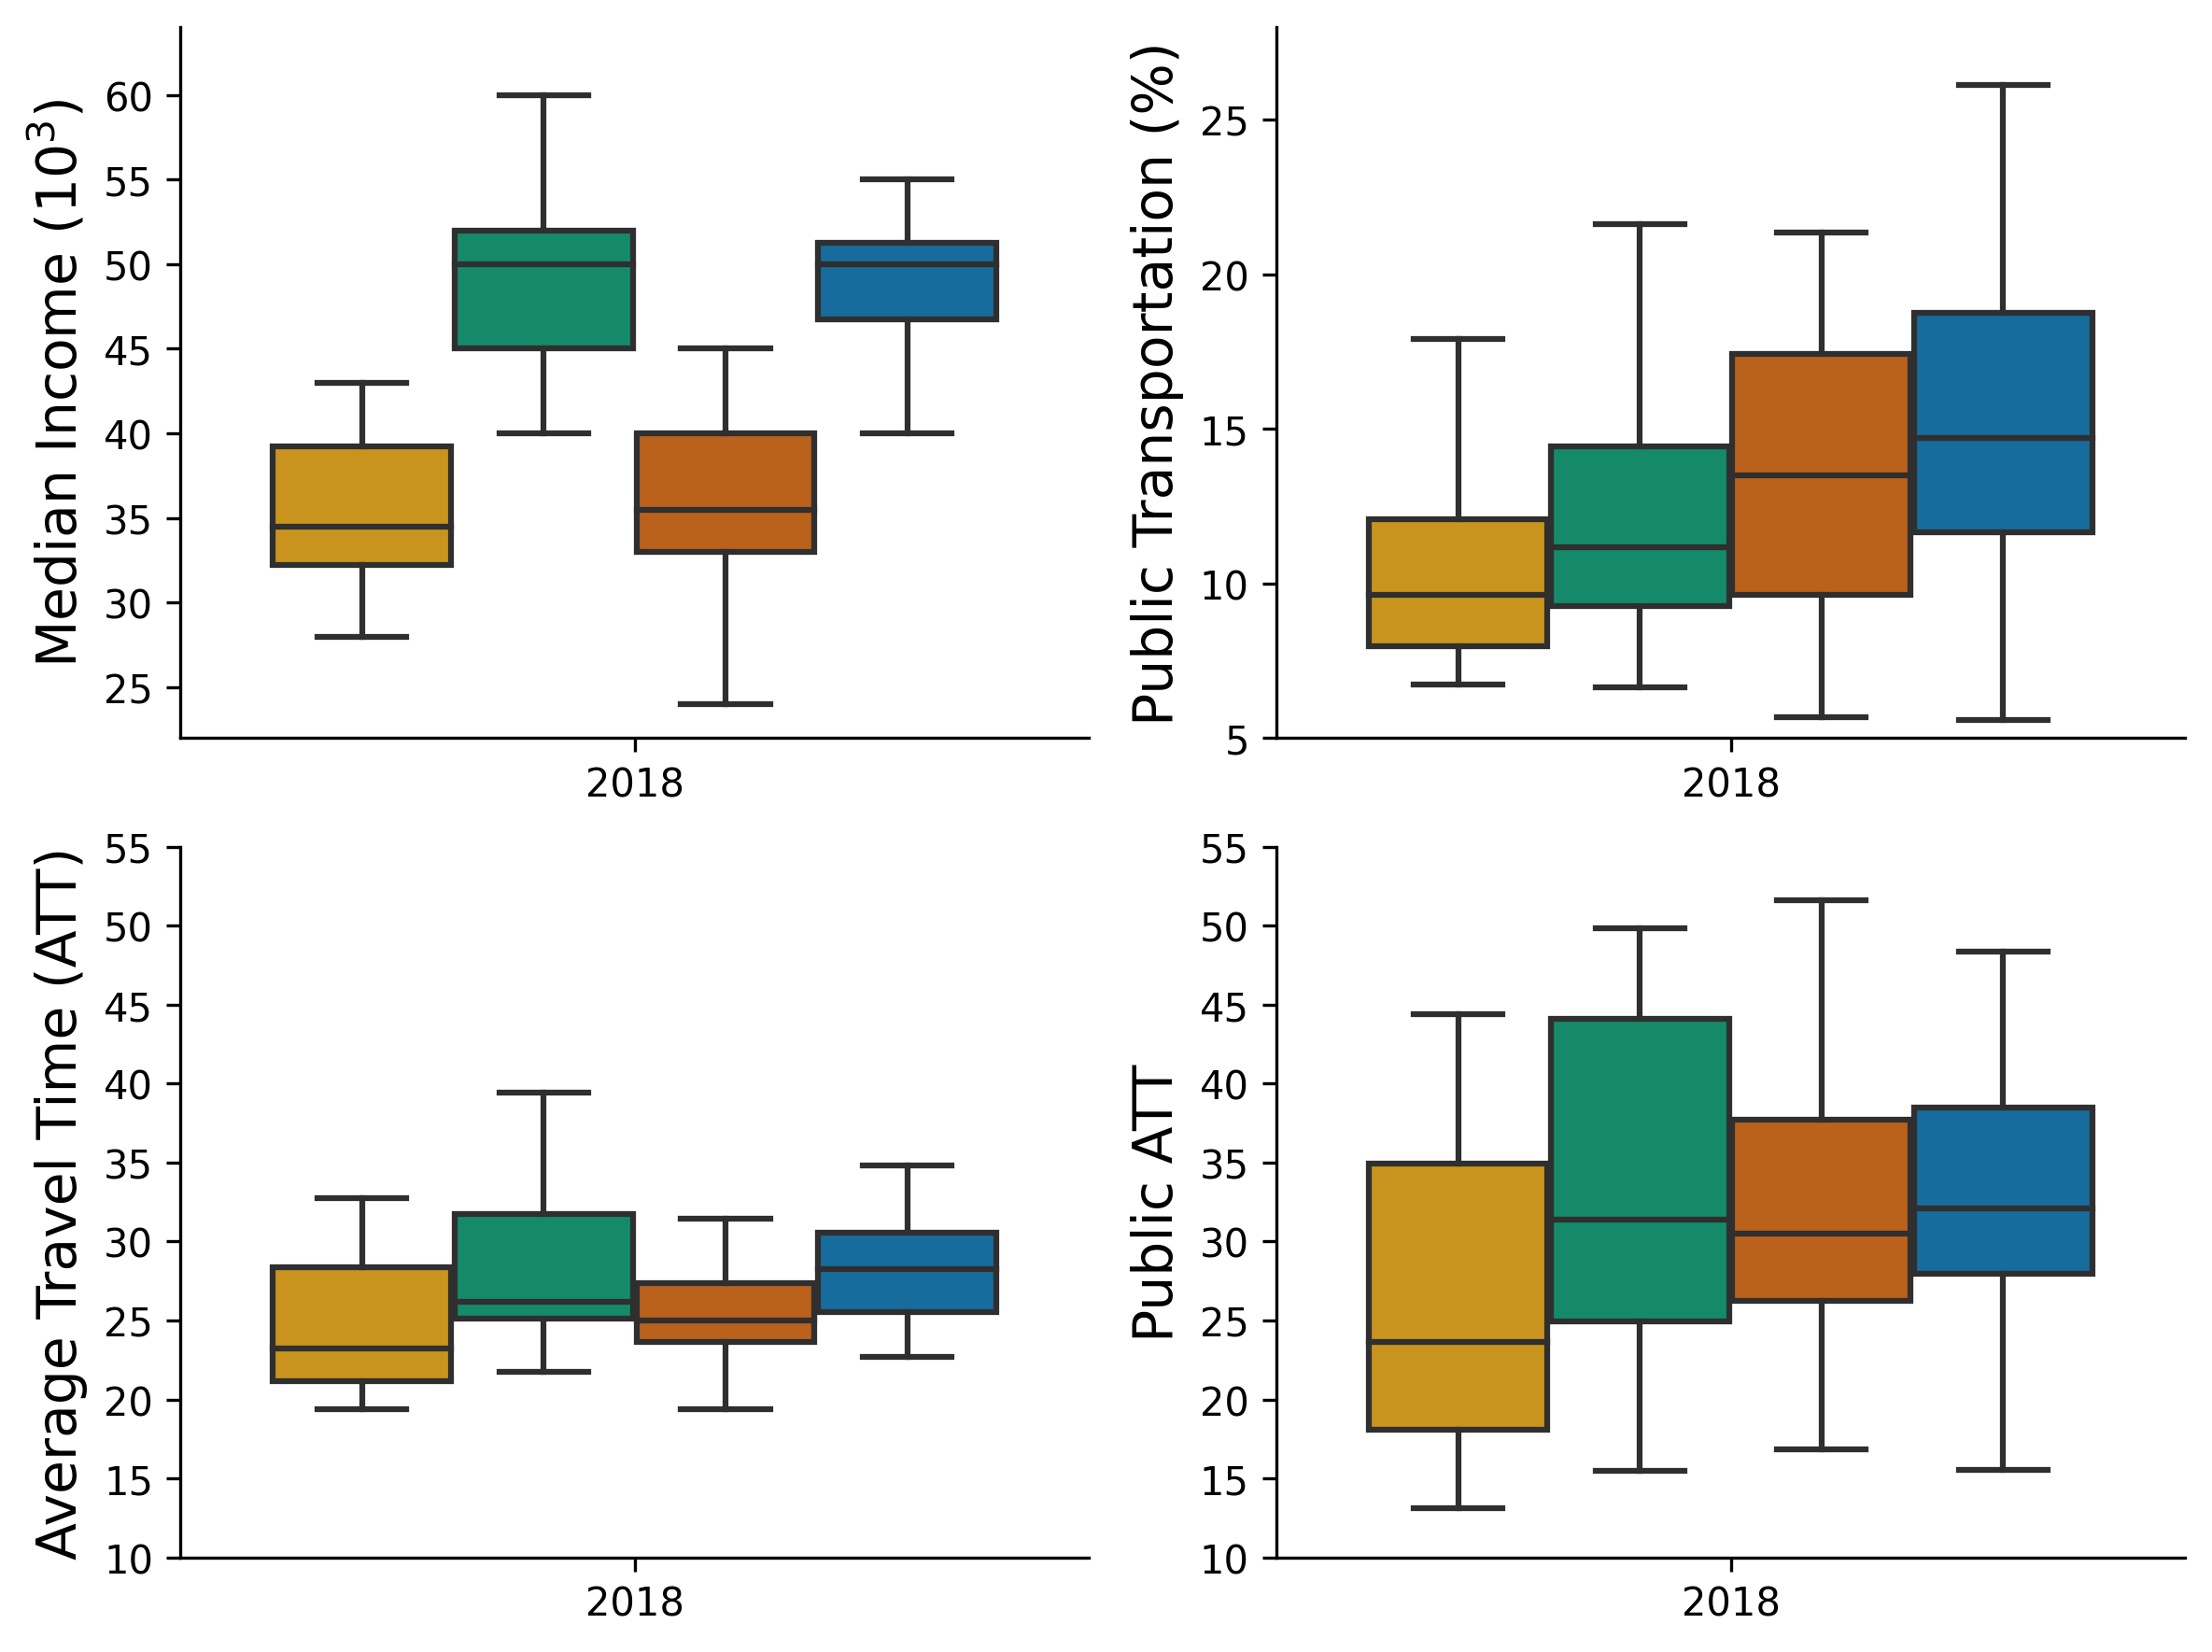

In [157]:
from scipy import stats
from scipy.stats import sem, t
confidence = 0.9
def get_error(a,each_result):
    if len(a) > 0:
        return sem(a[1][each_result], nan_policy='omit') * t.ppf((1 + confidence) / 2., len((a[1][each_result])-1))
    return 0

fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(4*2, 2*3), dpi=300)
import matplotlib.ticker as ticker
for each_row in range(2):
    for each_col in range(2):
        
        if each_col == 1 and each_row ==0:
            subset = data[['CITY','YEAR','GENDER','TRANSPORT_2','INDIVIDUAL_EXPANSION_FACTOR']].copy()
            aux_1 = subset.groupby(['CITY','YEAR','GENDER','TRANSPORT_2'])['INDIVIDUAL_EXPANSION_FACTOR'].sum().reset_index()
            aux_1 = aux_1.merge(file_per_city, left_on=['CITY','YEAR'], right_on=['city','year'])
            aux_1['total']= None
            for row in aux_1.groupby(['CITY','YEAR','GENDER'])['INDIVIDUAL_EXPANSION_FACTOR'].sum().reset_index().iterrows():
                aux_1.loc[(aux_1['CITY']==row[1]['CITY']) &\
                          (aux_1['YEAR']==row[1]['YEAR']),'total'] = row[1]['INDIVIDUAL_EXPANSION_FACTOR']
            aux_1['percentage'] = aux_1['INDIVIDUAL_EXPANSION_FACTOR']*100/aux_1['total']
            aux_1['group'] = aux_1['GENDER'].apply(str) + " " + aux_1['cluster'].apply(str)
            sns.boxplot(x='year', 
                    y='percentage', fliersize=0,
                    data=aux_1[(aux_1['TRANSPORT_2']=="Public") & 
                              (aux_1['year']==2018)].sort_values(by='cluster'),\
                        hue_order=['Women C1','Men C1','Women C2','Men C2'],\
                        hue='group', palette=colors, ax=ax[each_row][each_col])
            ax[each_row][each_col].set_ylim(5, 28)
            ax[each_row][each_col].set_xlabel("")
            ax[each_row][each_col].get_legend().remove()
            ax[each_row][each_col].set_ylabel("Public Transportation (%)", fontsize=14)
            del aux_1

            
        elif each_col == 0 and each_row ==1:
            aux_1 = data[(~data['TRAVEL_TIME'].isna()) & (data['TRAVEL_TIME']>0) 
                        & (data['RELATIONSHIP'].isin([20,21]))].groupby(['YEAR','CITY','GENDER'])[['TRAVEL_TIME','INDIVIDUAL_EXPANSION_FACTOR']]\
                        .apply(lambda x: np.sum(x['TRAVEL_TIME']*x['INDIVIDUAL_EXPANSION_FACTOR'])/x['INDIVIDUAL_EXPANSION_FACTOR'].sum()
                              ).reset_index()
            aux_1.columns = ['YEAR','CITY','GENDER','TRAVEL_TIME']
            aux_1 = aux_1.merge(file_per_city, left_on=['CITY','YEAR'], right_on=['city','year'])
            aux_1['group'] = aux_1['GENDER'].apply(str) + " " + aux_1['cluster'].apply(str)
            sns.boxplot(x='year', 
                    y='TRAVEL_TIME', fliersize=0,
                    data=aux_1[(aux_1['year']==2018)].sort_values(by='cluster'),\
                        hue='group', palette=colors,hue_order=['Women C1','Men C1','Women C2','Men C2'],
                        ax=ax[each_row][each_col])
            ax[each_row][each_col].set_ylim(10, 55)
            ax[each_row][each_col].get_legend().remove()
            ax[each_row][each_col].set_xlabel("")
            ax[each_row][each_col].set_ylabel("Average Travel Time (ATT)", fontsize=14)
            del aux_1

        elif each_col == 1 and each_row ==1:
            aux_1 = data[(~data['TRAVEL_TIME'].isna()) & (data['TRAVEL_TIME']>0) & (data['TRANSPORT_2']=="Public")
                        & (data['RELATIONSHIP'].isin([20,21]))].groupby(['YEAR','CITY','GENDER'])[['TRAVEL_TIME','INDIVIDUAL_EXPANSION_FACTOR']]\
                        .apply(lambda x: np.sum(x['TRAVEL_TIME']*x['INDIVIDUAL_EXPANSION_FACTOR'])/x['INDIVIDUAL_EXPANSION_FACTOR'].sum()
                              ).reset_index()
            aux_1.columns = ['YEAR','CITY','GENDER','TRAVEL_TIME']
            aux_1 = aux_1.merge(file_per_city, left_on=['CITY','YEAR'], right_on=['city','year'])
            aux_1['group'] = aux_1['GENDER'].apply(str) + " " + aux_1['cluster'].apply(str)
            sns.boxplot(x='year', 
                    y='TRAVEL_TIME', fliersize=0,
                    data=aux_1[(aux_1['year']==2018)].sort_values(by='cluster'),\
                        hue='group', hue_order=['Women C1','Men C1','Women C2','Men C2'], \
                        palette=colors, ax=ax[each_row][each_col])
            ax[each_row][each_col].set_ylim(10, 55)
            ax[each_row][each_col].get_legend().remove()
            ax[each_row][each_col].set_xlabel("")
            ax[each_row][each_col].set_ylabel("Public ATT", fontsize=14)
            del aux_1




            
        elif each_col == 0 and each_row ==0:
            aux_1 = data[(~data['TRAVEL_TIME'].isna()) & (data['TRAVEL_TIME']>0)
                        & (data['RELATIONSHIP'].isin([20,21]))][['YEAR','CITY','GENDER','INDIVIDUAL_INCOME','INDIVIDUAL_EXPANSION_FACTOR']].copy()
            aux_1 = aux_1.loc[aux_1.index.repeat(aux_1['INDIVIDUAL_EXPANSION_FACTOR'])].copy()
            aux_1 = aux_1.groupby(['YEAR','CITY','GENDER'])['INDIVIDUAL_INCOME'].median().reset_index()
            aux_1['INDIVIDUAL_INCOME'] = (aux_1['INDIVIDUAL_INCOME']/1000).astype(int)
            aux_1 = aux_1.merge(file_per_city, left_on=['CITY','YEAR'], right_on=['city','year'])
            aux_1['group'] = aux_1['GENDER'].apply(str) + " " + aux_1['cluster'].apply(str)
            sns.boxplot(x='year', 
                    y='INDIVIDUAL_INCOME', fliersize=0,
                    data=aux_1[(aux_1['year']==2018)].sort_values(by='cluster'),\
                        hue='group',hue_order=['Women C1','Men C1','Women C2','Men C2'],\
                        palette=colors, ax=ax[each_row][each_col])
            ax[each_row][each_col].set_ylim(22, 64)
            ax[each_row][each_col].get_legend().remove()
            ax[each_row][each_col].set_xlabel("")
            ax[each_row][each_col].set_ylabel("Median Income ($10^{3}$)", fontsize=14)
            del aux_1
            

        
        ax[each_row][each_col].spines['top'].set_visible(False)
        ax[each_row][each_col].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("cluster_image1_2rows_gender.pdf")




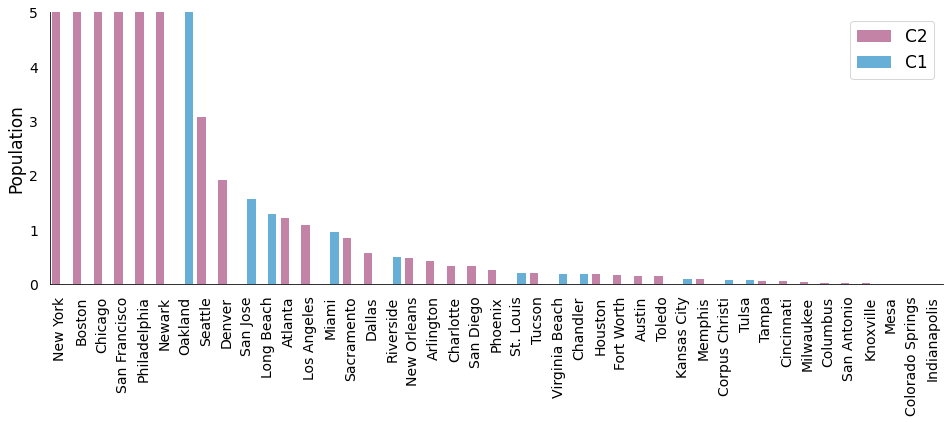

In [45]:
fontsize_all = 14
for year in range(2018,2019):
    fig, ax = plt.subplots(figsize=(16,5))
    sns.barplot(data=aux_1[(aux_1['YEAR']==year) & (aux_1['GENDER']=="Women") &\
                           (aux_1['MAIN_TRANSPORTATION']=="Public")].sort_values(by='percentage', ascending=False),\
                x='CITY', y='percentage',
                hue='cluster', palette=colors, ax=ax)
    leg = ax.legend(loc='upper right',fontsize=17)
    for line in leg.get_lines():
        line.set_linewidth(3.0)

    ax.tick_params(axis='both',length=0,labelsize=fontsize_all,pad=12)
    ax.tick_params(axis='both',which='minor',length=2)
    ax.tick_params(axis='x',rotation=90)
    
    ax.set_ylim(0,5)
    sns.despine()
    import matplotlib.ticker as ticker
    ax.yaxis.set_major_locator(ticker.LinearLocator(numticks=6))
    y_fmt = ticker.FormatStrFormatter('%d')
    ax.yaxis.set_major_formatter(y_fmt)


    ax.set_ylabel("Population",fontsize=17)
    ax.set_xlabel("",fontsize=17)
    plt.savefig("../datasets/order_public_%d.pdf"%year,  bbox_inches="tight")